In [1]:
%%time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import matplotlib.cm as cm
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
import numpy as np

CPU times: total: 1.77 s
Wall time: 2.27 s


In [2]:
DATA_DIR = Path("./outputs")  

extreme_sensitivity_files = ["extreme_sensitivity_results_Machine Learning Models_Horizon12.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Coin.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Funding_Positioning.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Onchain.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Open_Interest.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Order_Book.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Price_Volume.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Social.xlsx",
                             "extreme_sensitivity_results_Machine Learning Models-Without_Time.xlsx",]

test_cumulative_files = ["test_cumulative_results_Machine Learning Models_Horizon12.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Coin.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Funding_Positioning.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Onchain.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Open_Interest.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Order_Book.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Price_Volume.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Social.xlsx",
                         "test_cumulative_results_Machine Learning Models-Without_Time.xlsx",]

def read_and_union(filenames):
    dfs = []
    for name in filenames:
        df = pd.read_excel(DATA_DIR / name)
        df["source_file"] = name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

df_extreme_sensitivity = read_and_union(extreme_sensitivity_files)
df_test_cumulative = read_and_union(test_cumulative_files)

print(df_extreme_sensitivity.shape)
print(df_test_cumulative.shape)

(648, 15)
(36, 12)


In [3]:
df_extreme_sensitivity.columns

Index(['Script name', 'Extreme percentile', 'Model', 'Test PR-AUC',
       'PR-AUC lift over random', 'Test precision', 'Test recall', 'Test F1',
       'Number of test extremes', 'True positives', 'False positives',
       'False negatives', 'True negatives', 'Coins with defined PR-AUC',
       'source_file'],
      dtype='object')

In [4]:
df_test_cumulative.columns

Index(['Script name', 'Model', 'MAE', 'RMSE', 'R2', 'RMSLE', 'Mean error',
       'Actual mean', 'Prediction mean', 'Actual median', 'Prediction median',
       'source_file'],
      dtype='object')

## Regression Grids

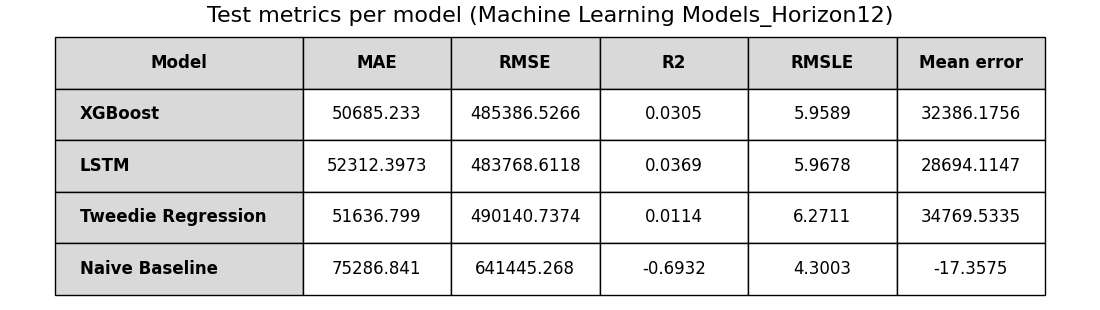

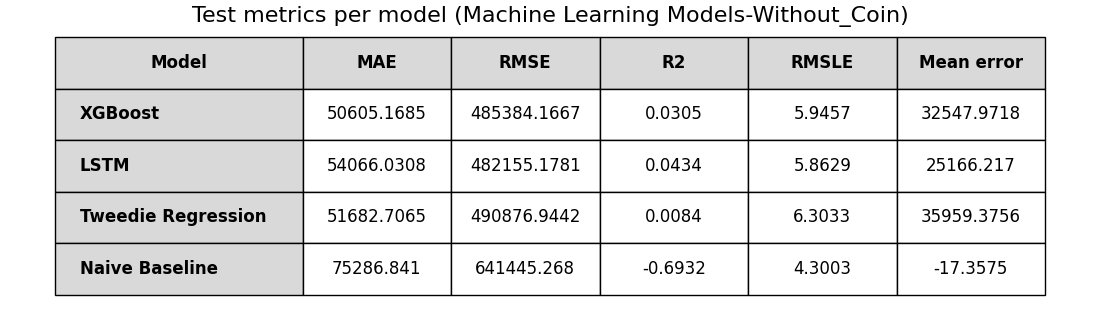

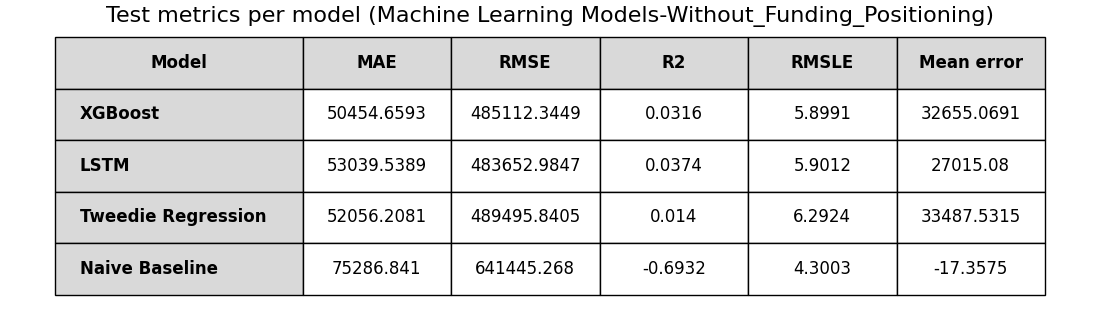

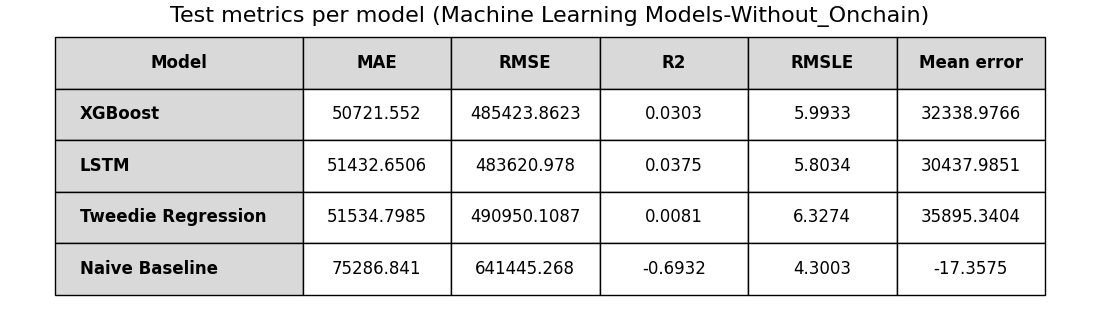

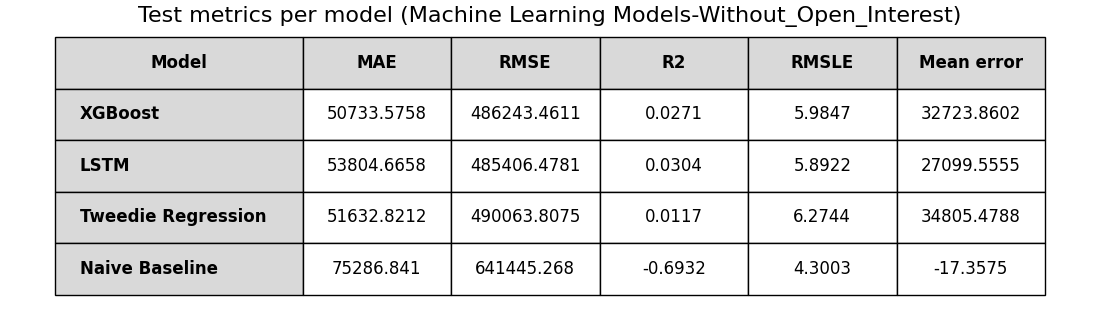

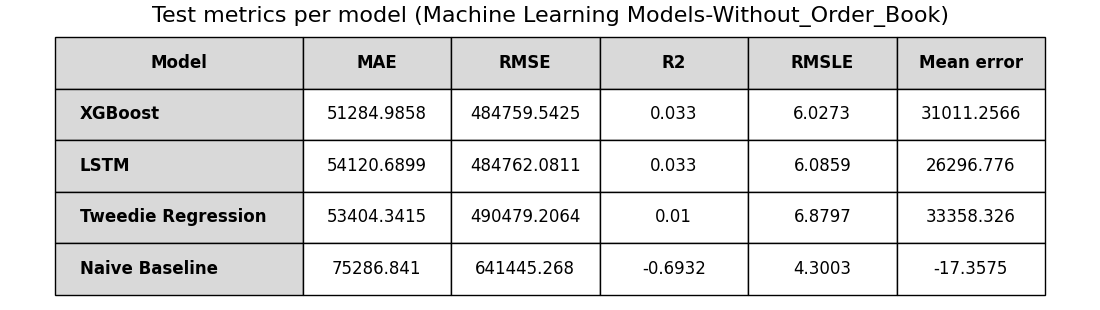

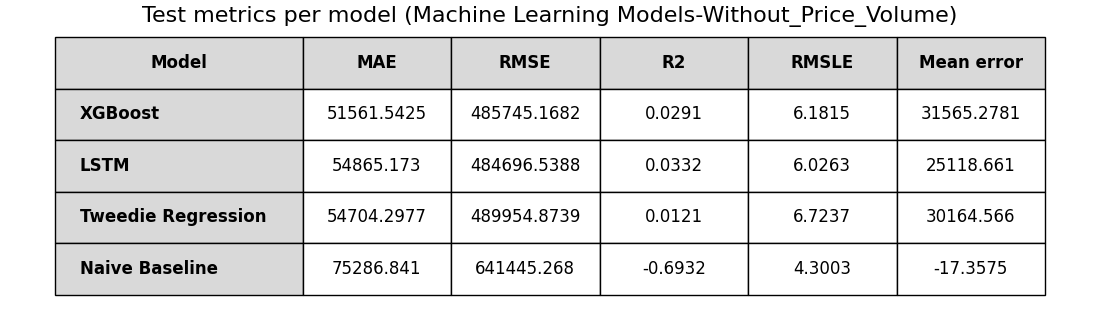

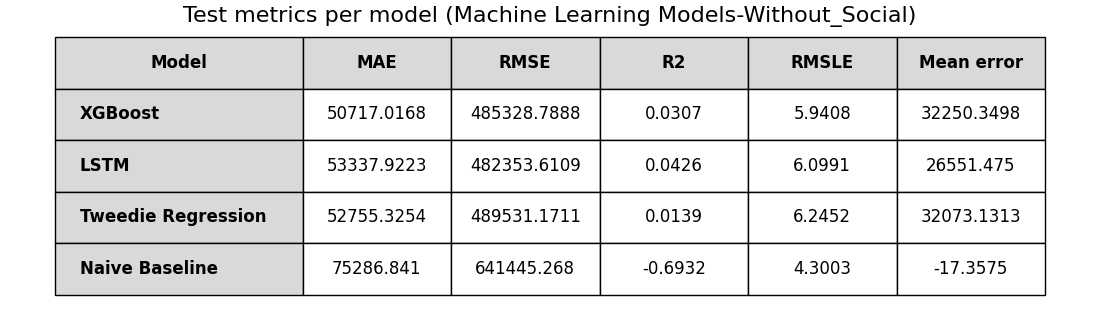

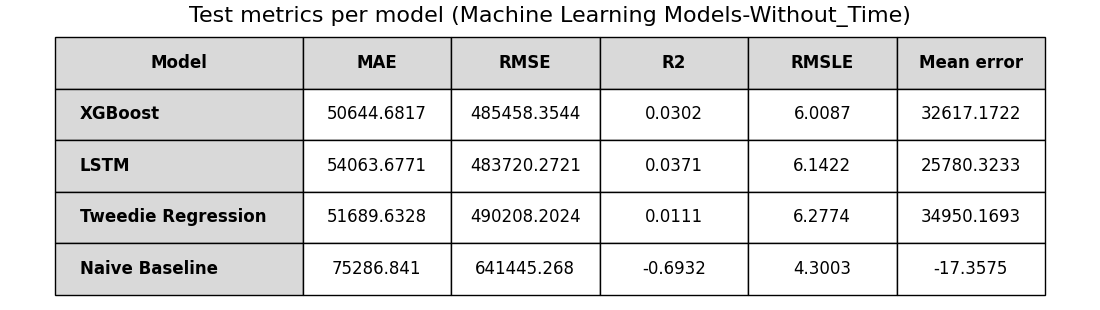

In [5]:

script_names = df_test_cumulative['Script name'].unique()
metric_cols = ['MAE', 'RMSE', 'R2', 'RMSLE', 'Mean error']
MODEL_ORDER = ['XGBoost', 'LSTM', 'Tweedie Regression', 'Previous 12-row liquidation sum']
DISPLAY_NAMES = {'Previous 12-row liquidation sum': 'Naive Baseline'}

for script in script_names:
    subset = df_test_cumulative[df_test_cumulative['Script name'] == script]
    title = f'Test metrics per model ({script})'
    
    models = [m for m in MODEL_ORDER if m in subset['Model'].unique()]
    
    grid = subset.set_index('Model').loc[models, metric_cols].round(4)
    
    n_rows = len(grid) + 1
    table_height = n_rows * 0.5 + 0.6
    
    fig, ax = plt.subplots(figsize=(11, table_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    wrapped_cols = [textwrap.fill(c, 12) for c in grid.columns]
    display_row_names = [DISPLAY_NAMES.get(m, m) for m in grid.index]
    wrapped_rows = [textwrap.fill(m, 30) for m in display_row_names]
    
    col_labels = ['Model'] + wrapped_cols
    cell_text = [[wrapped_rows[i]] + list(grid.iloc[i].astype(str)) for i in range(len(grid))]
    
    table = ax.table(cellText=cell_text,colLabels=col_labels,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    
    # same fixed widths
    for (row, col), cell in table.get_celld().items():
        cell.set_width(0.25 if col == 0 else 0.15)
    
    # header row formatting
    for col_idx in range(len(col_labels)):
        cell = table[(0, col_idx)]
        cell.set_facecolor('#d9d9d9')
        cell.set_text_props(color='black', weight='bold')
    
    # first column formatting
    for row_idx in range(1, len(grid) + 1):
        cell = table[(row_idx, 0)]
        cell.set_facecolor('#d9d9d9')
        cell.set_text_props(color='black', weight='bold')
        cell.set_text_props(ha='left')
    
    fig.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.05)
    fig.suptitle(title, fontsize=16, x=0.5, ha='center')
    
    plt.show()

### Ablation study on RMSE

In [6]:

full_script = [s for s in df_test_cumulative['Script name'].unique() if 'horizon12' in s.lower()][0]
feature_scripts = [s for s in df_test_cumulative['Script name'].unique() if 'without_' in s.lower()]

full_df = df_test_cumulative[(df_test_cumulative['Script name'] == full_script) &(~df_test_cumulative['Model'].str.lower().str.contains('liquidation sum'))]

rows = []
for script in feature_scripts:
    feature_group = script.split('Without_')[-1]
    variant_df = df_test_cumulative[(df_test_cumulative['Script name'] == script) &(~df_test_cumulative['Model'].str.lower().str.contains('liquidation sum'))]
    
    merged = variant_df.merge(full_df,on='Model',suffixes=('_without', '_full'))
    merged['rmse_change'] = merged['RMSE_without'] - merged['RMSE_full']
    
    change = merged.set_index('Model')['rmse_change']
    change.name = feature_group
    rows.append(change)

ablation_rmse = pd.DataFrame(rows) 
ablation_rmse = ablation_rmse.round(4)
ablation_rmse

Model,Tweedie Regression,LSTM,XGBoost
Coin,736.2068,-1613.4338,-2.3598
Funding_Positioning,-644.8969,-115.6272,-274.1816
Onchain,809.3713,-147.6338,37.3357
Open_Interest,-76.9299,1637.8663,856.9345
Order_Book,338.4690,993.4692,-626.9841
Price_Volume,-185.8635,927.9269,358.6417
Social,-609.5663,-1415.0009,-57.7378
Time,67.4650,-48.3397,71.8279


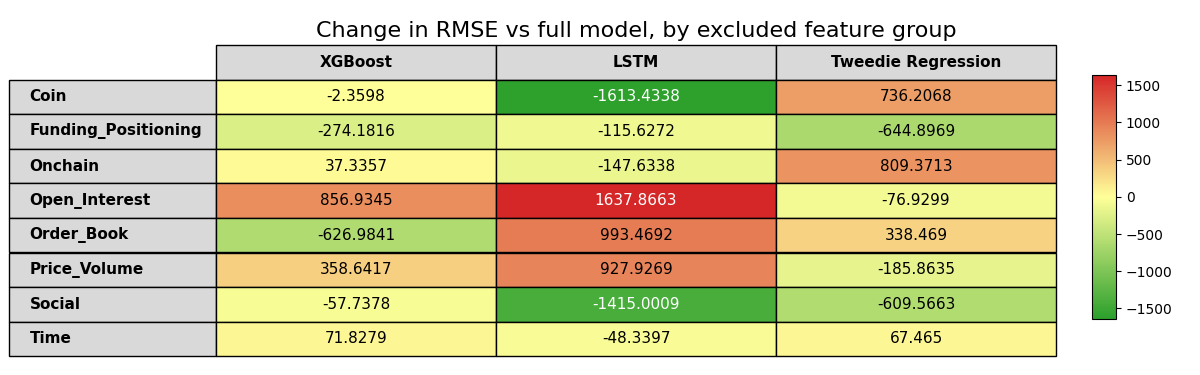

In [7]:

MODEL_ORDER = ['XGBoost', 'LSTM', 'Tweedie Regression']
models = [m for m in MODEL_ORDER if m in ablation_rmse.columns]
ablation_rmse = ablation_rmse[models]

n_rows = len(ablation_rmse) + 1
table_height = n_rows * 0.35 + 0.6
fig, ax = plt.subplots(figsize=(12, table_height))
ax.axis('off')
ax.set_title('Change in RMSE vs full model, by excluded feature group', fontsize=16, pad=6)
table = ax.table(cellText=ablation_rmse.values, rowLabels=ablation_rmse.index,colLabels=ablation_rmse.columns,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)

# column header formatting
for col_idx in range(len(ablation_rmse.columns)):
    cell = table[(0, col_idx)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')

# row header formatting
for row_idx in range(1, len(ablation_rmse) + 1):
    cell = table[(row_idx, -1)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')

# colour scale for conditional formatting
green_red = LinearSegmentedColormap.from_list('green_yellow_red', ['#2ca02c', '#ffff99', '#d62728'])
max_abs = ablation_rmse.values.max() if abs(ablation_rmse.values.max()) > abs(ablation_rmse.values.min()) else abs(ablation_rmse.values.min())
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

for row_idx, feature_group in enumerate(ablation_rmse.index, start=1):
    for col_idx, model in enumerate(ablation_rmse.columns):
        val = ablation_rmse.loc[feature_group, model]
        cell = table[(row_idx, col_idx)]
        cell.set_facecolor(green_red(norm(val)))
        intensity = abs(norm(val) - 0.5) * 2
        cell.set_text_props(color='white' if intensity > 0.75 else 'black')

fig.subplots_adjust(left=0.18, right=0.88, top=0.88, bottom=0.05)

cax = fig.add_axes([0.91, 0.15, 0.02, 0.65])
sm = cm.ScalarMappable(norm=norm, cmap=green_red)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
plt.show()

### Ablation study on R-Squared

In [8]:

full_script = [s for s in df_test_cumulative['Script name'].unique() if 'horizon12' in s.lower()][0]
feature_scripts = [s for s in df_test_cumulative['Script name'].unique() if 'without_' in s.lower()]

full_df = df_test_cumulative[(df_test_cumulative['Script name'] == full_script) &(~df_test_cumulative['Model'].str.lower().str.contains('liquidation sum'))]

rows = []
for script in feature_scripts:
    feature_group = script.split('Without_')[-1]
    variant_df = df_test_cumulative[(df_test_cumulative['Script name'] == script) &(~df_test_cumulative['Model'].str.lower().str.contains('liquidation sum'))]
    
    merged = variant_df.merge(full_df,on='Model',suffixes=('_without', '_full'))
    merged['r2_change'] = merged['R2_without'] - merged['R2_full']
    
    change = merged.set_index('Model')['r2_change']
    change.name = feature_group
    rows.append(change)

ablation_r2 = pd.DataFrame(rows)  
ablation_r2 = ablation_r2.round(4)
ablation_r2

Model,Tweedie Regression,LSTM,XGBoost
Coin,-0.0030,0.0064,0.0000
Funding_Positioning,0.0026,0.0005,0.0011
Onchain,-0.0033,0.0006,-0.0001
Open_Interest,0.0003,-0.0065,-0.0034
Order_Book,-0.0014,-0.0040,0.0025
Price_Volume,0.0007,-0.0037,-0.0014
Social,0.0025,0.0056,0.0002
Time,-0.0003,0.0002,-0.0003


C:\Users\admin\AppData\Local\Temp\ipykernel_22312\2375422966.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  red_green = cm.get_cmap('RdYlGn')


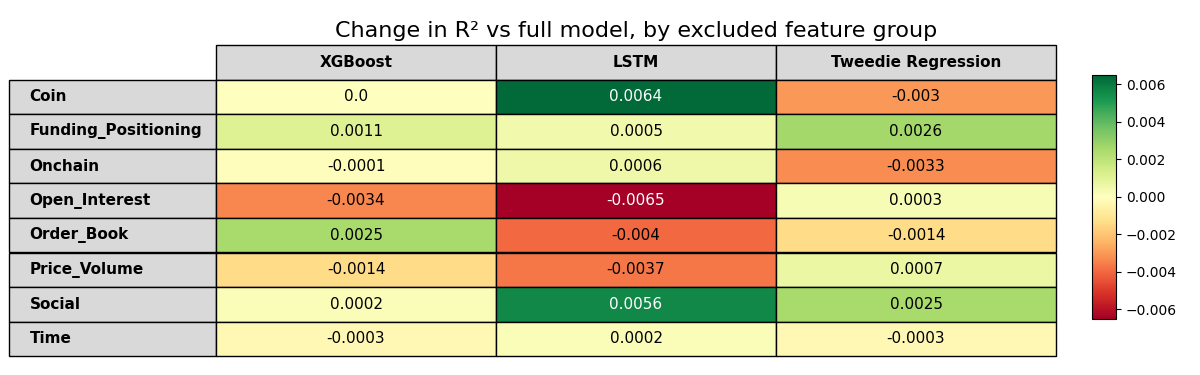

In [9]:

MODEL_ORDER = ['XGBoost', 'LSTM', 'Tweedie Regression']
models = [m for m in MODEL_ORDER if m in ablation_r2.columns]
ablation_r2 = ablation_r2[models]

n_rows = len(ablation_r2) + 1
table_height = n_rows * 0.35 + 0.6
fig, ax = plt.subplots(figsize=(12, table_height))
ax.axis('off')
ax.set_title('Change in R² vs full model, by excluded feature group', fontsize=16, pad=6)
table = ax.table(cellText=ablation_r2.values,rowLabels=ablation_r2.index,colLabels=ablation_r2.columns,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)

# column header formatting
for col_idx in range(len(ablation_r2.columns)):
    cell = table[(0, col_idx)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')

# row header formatting
for row_idx in range(1, len(ablation_r2) + 1):
    cell = table[(row_idx, -1)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')

# colour scale for conditional formatting
red_green = cm.get_cmap('RdYlGn')
max_abs = ablation_r2.values.max() if abs(ablation_r2.values.max()) > abs(ablation_r2.values.min()) else abs(ablation_r2.values.min())
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

for row_idx, feature_group in enumerate(ablation_r2.index, start=1):
    for col_idx, model in enumerate(ablation_r2.columns):
        val = ablation_r2.loc[feature_group, model]
        cell = table[(row_idx, col_idx)]
        cell.set_facecolor(red_green(norm(val)))
        intensity = abs(norm(val) - 0.5) * 2
        cell.set_text_props(color='white' if intensity > 0.75 else 'black')

fig.subplots_adjust(left=0.18, right=0.88, top=0.88, bottom=0.05)

cax = fig.add_axes([0.91, 0.15, 0.02, 0.65])
sm = cm.ScalarMappable(norm=norm, cmap=red_green)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
plt.show()

## PR-AUC Charts

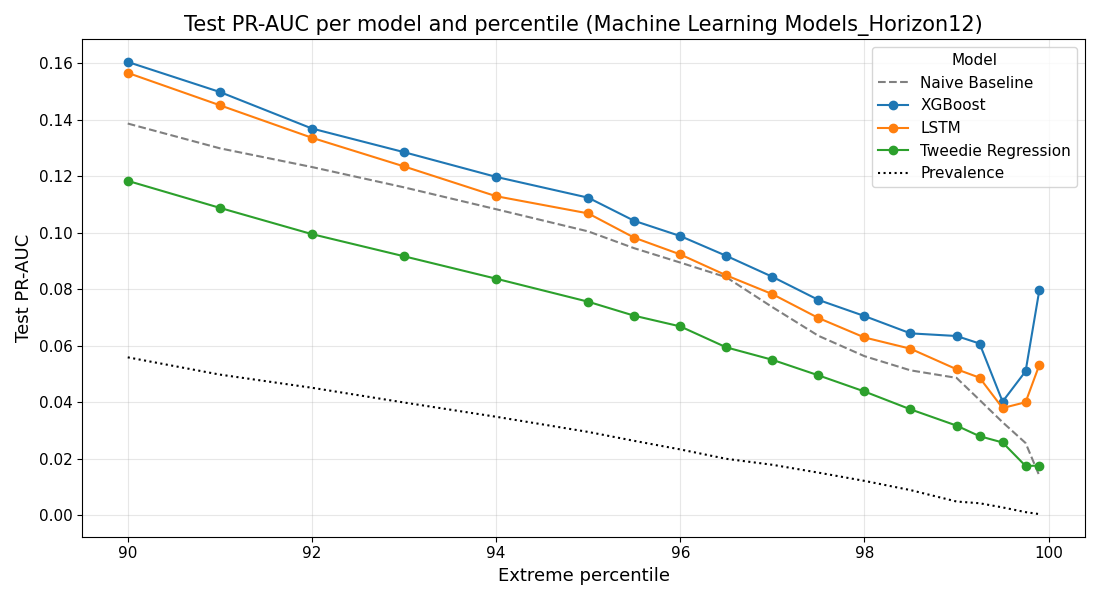

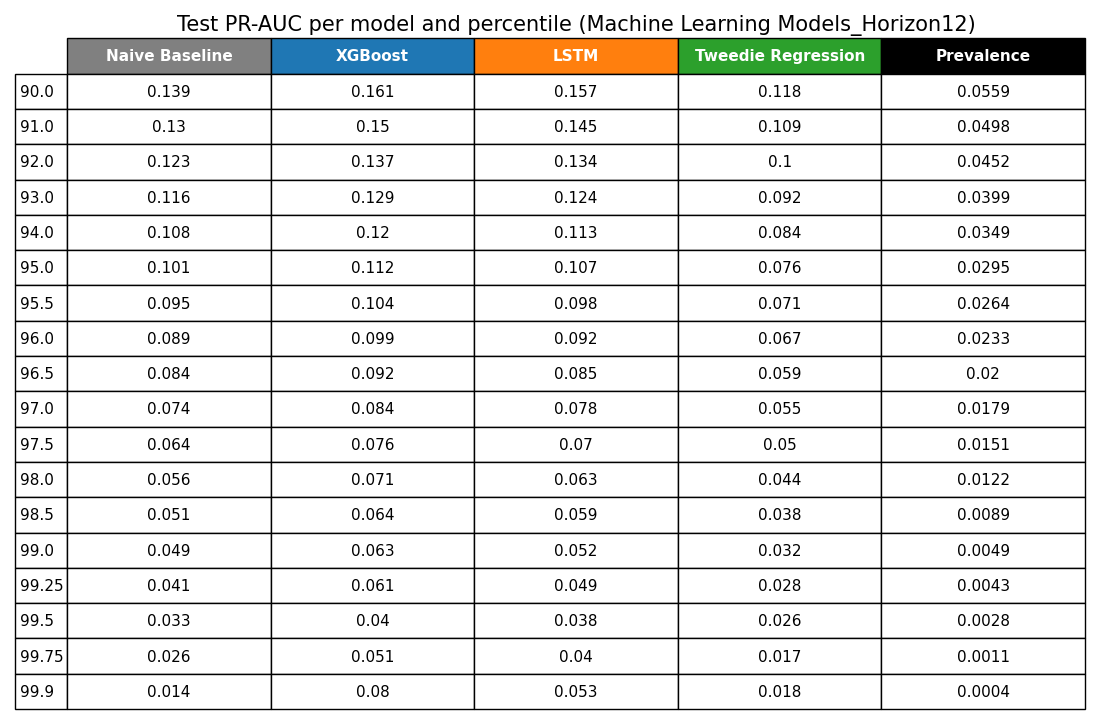

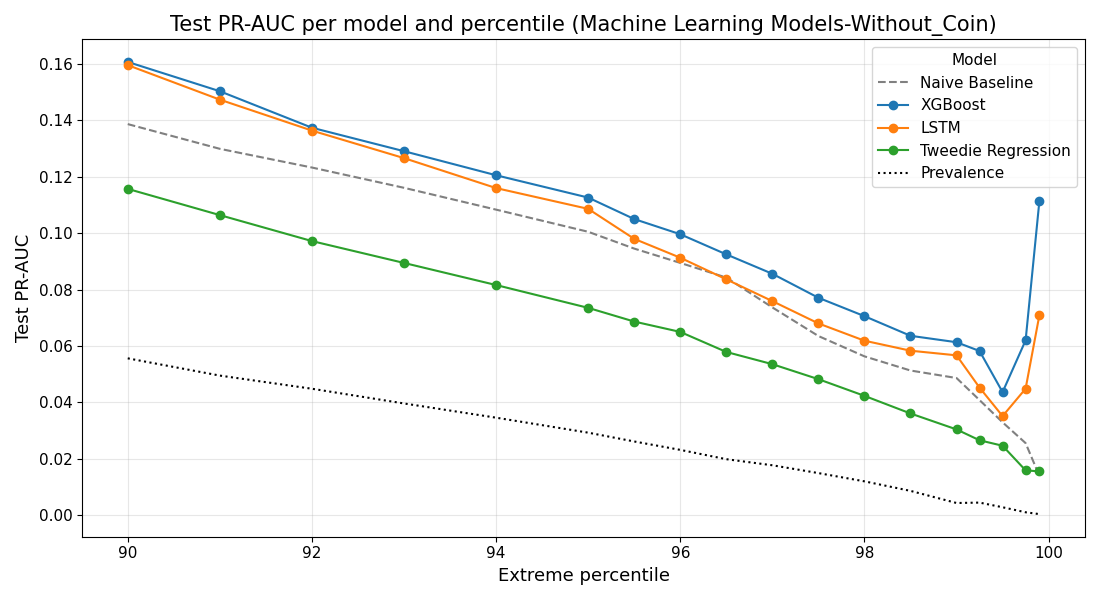

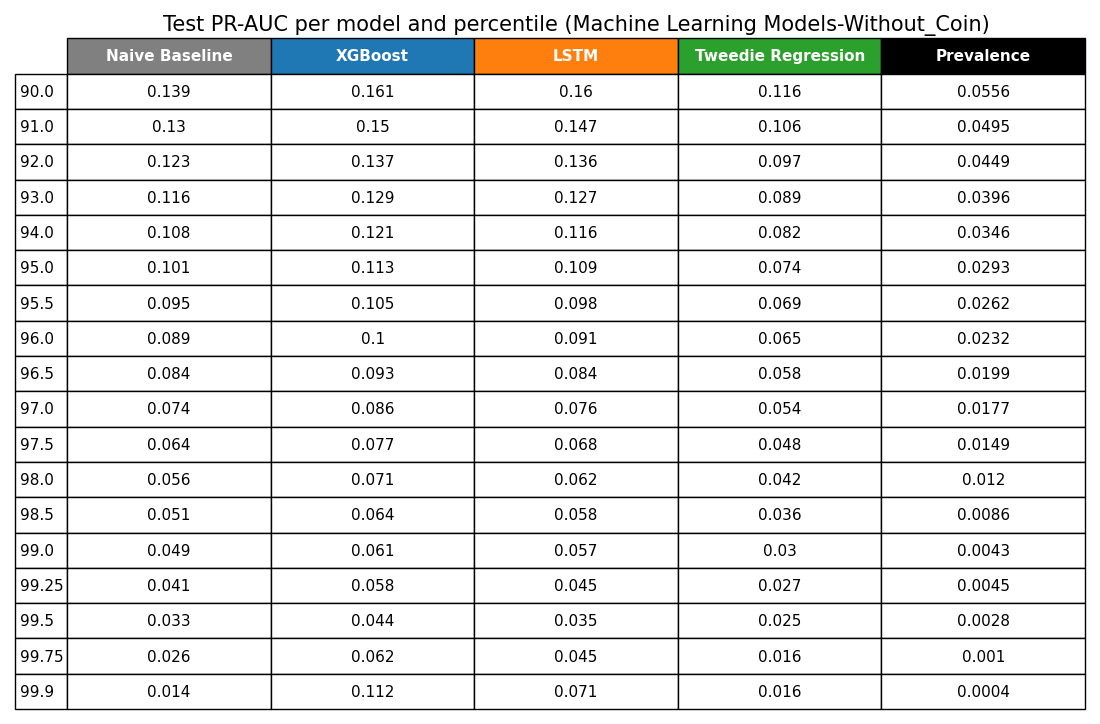

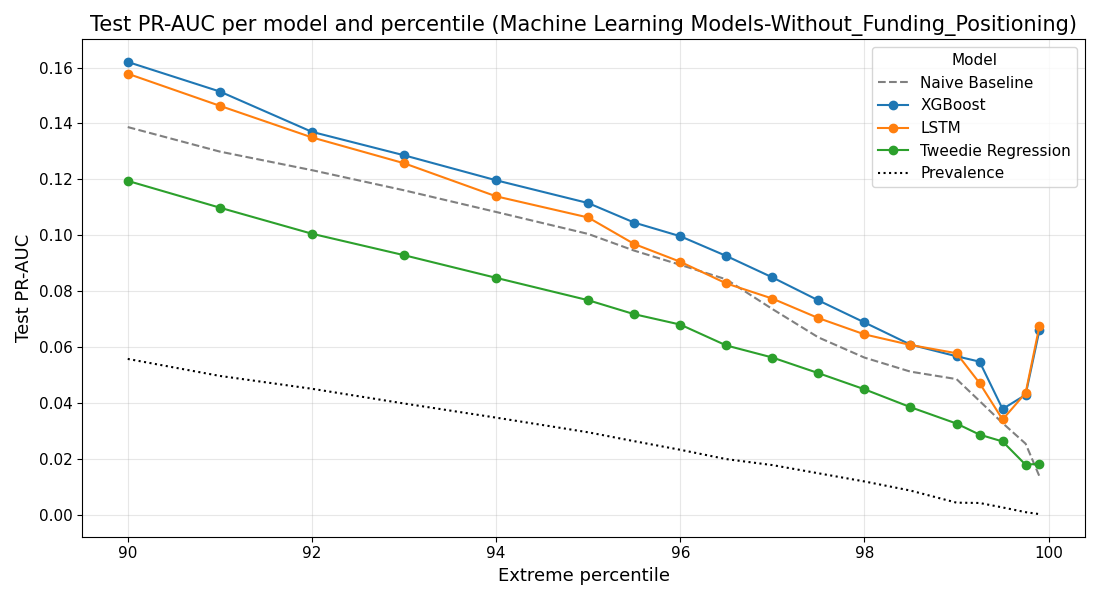

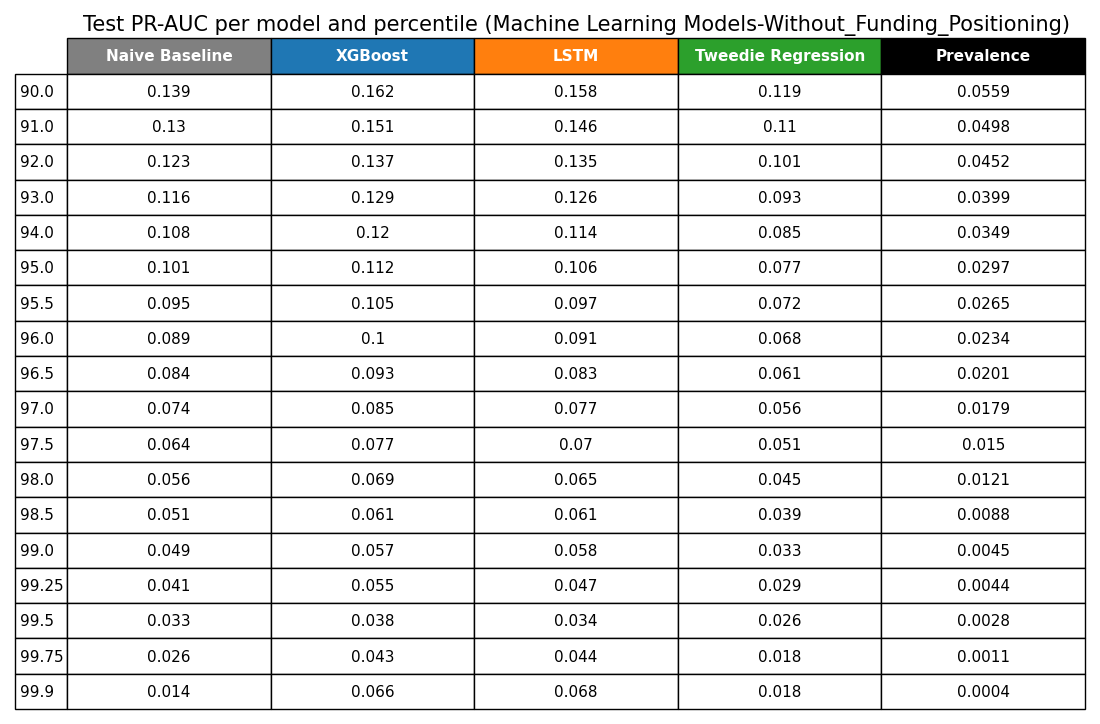

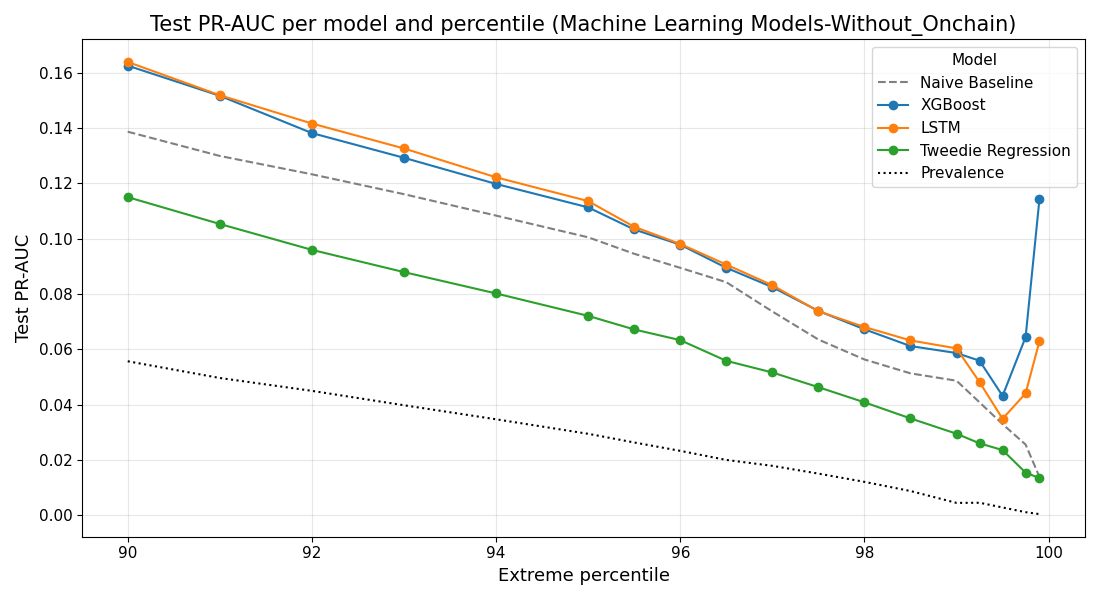

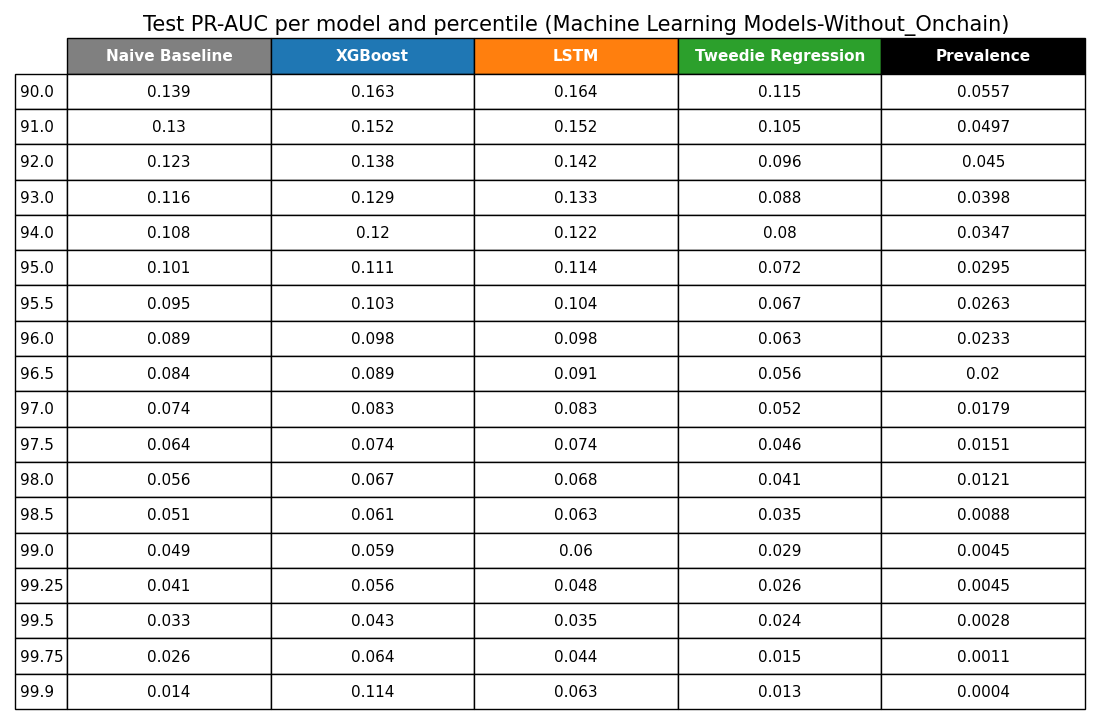

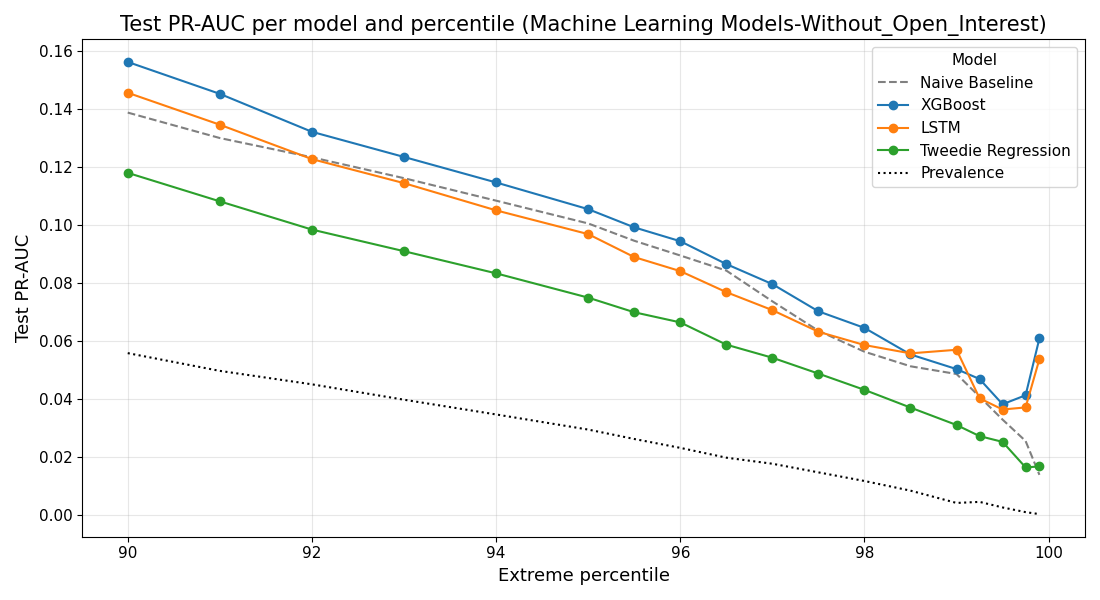

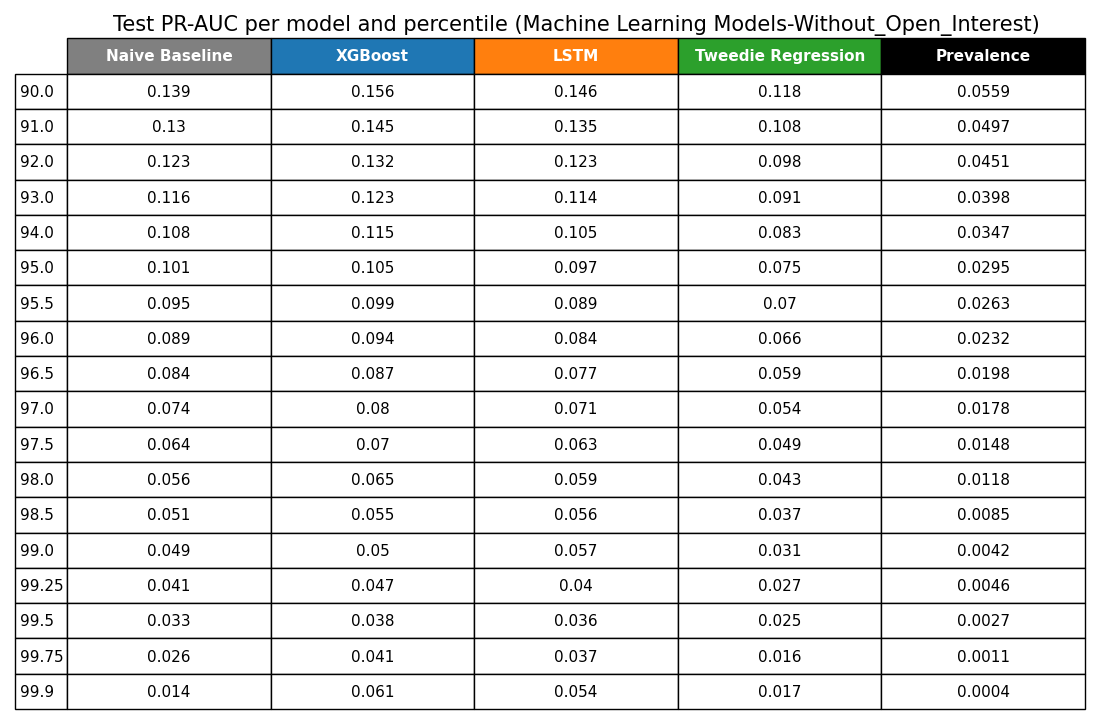

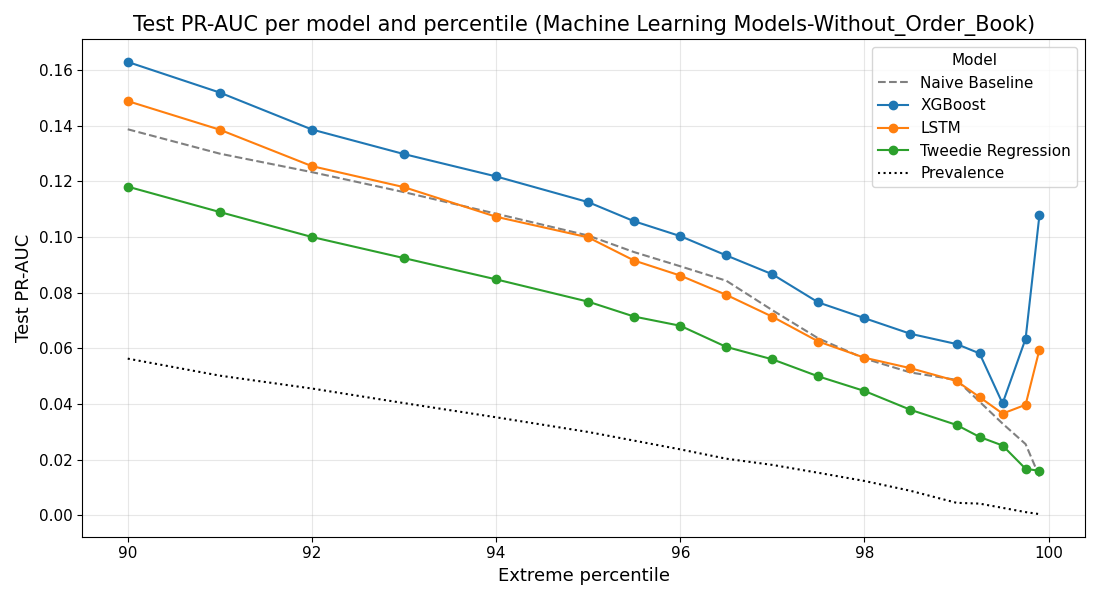

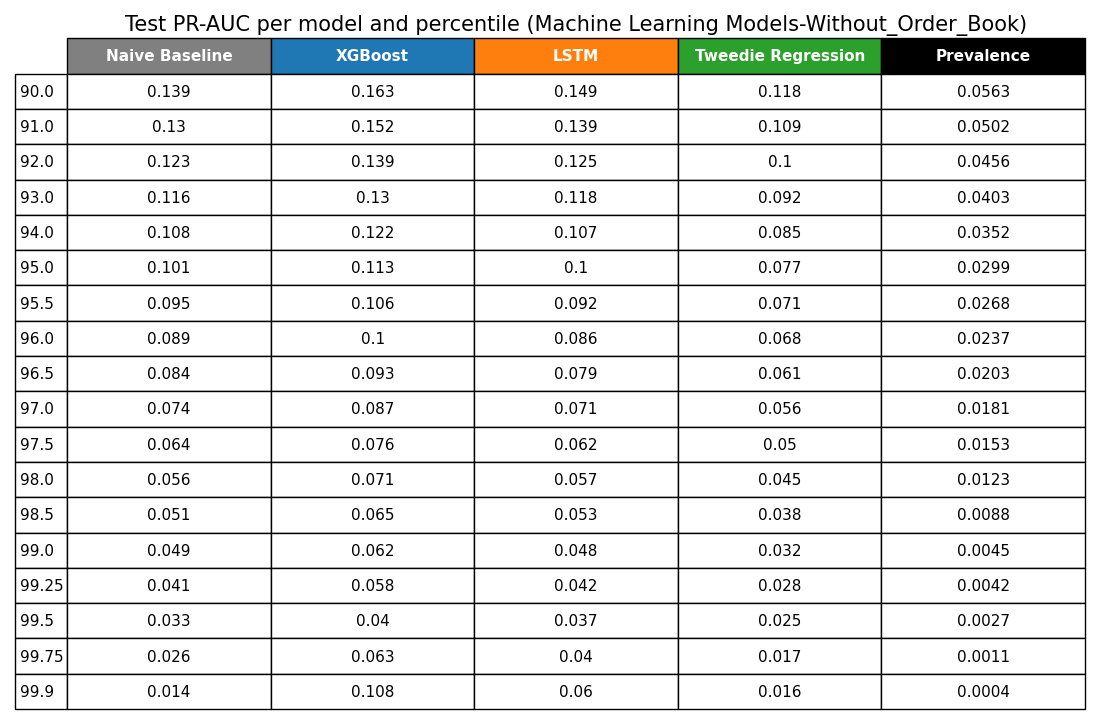

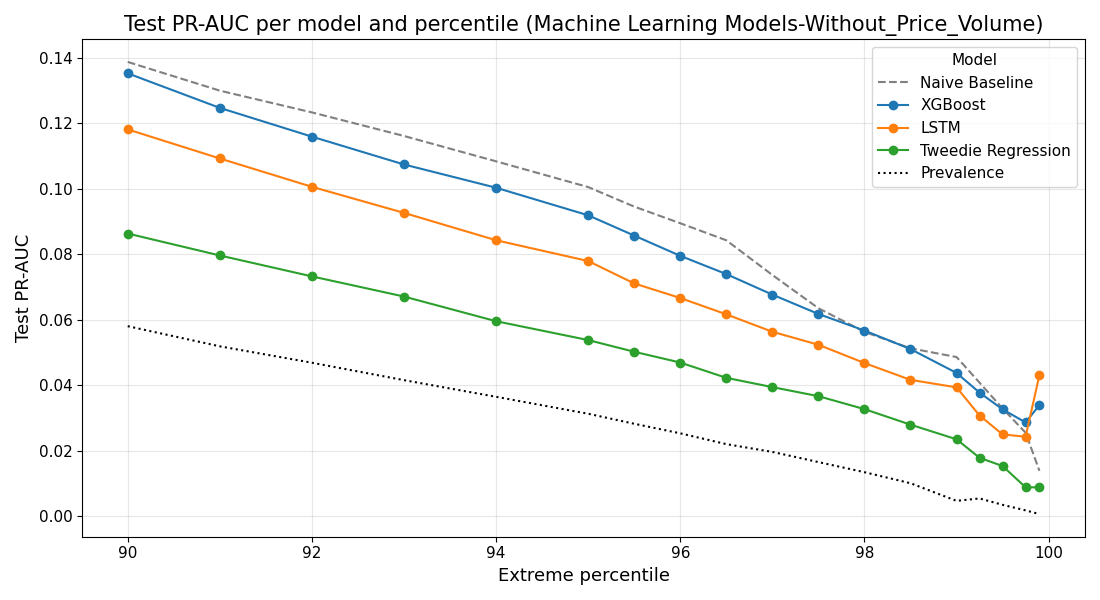

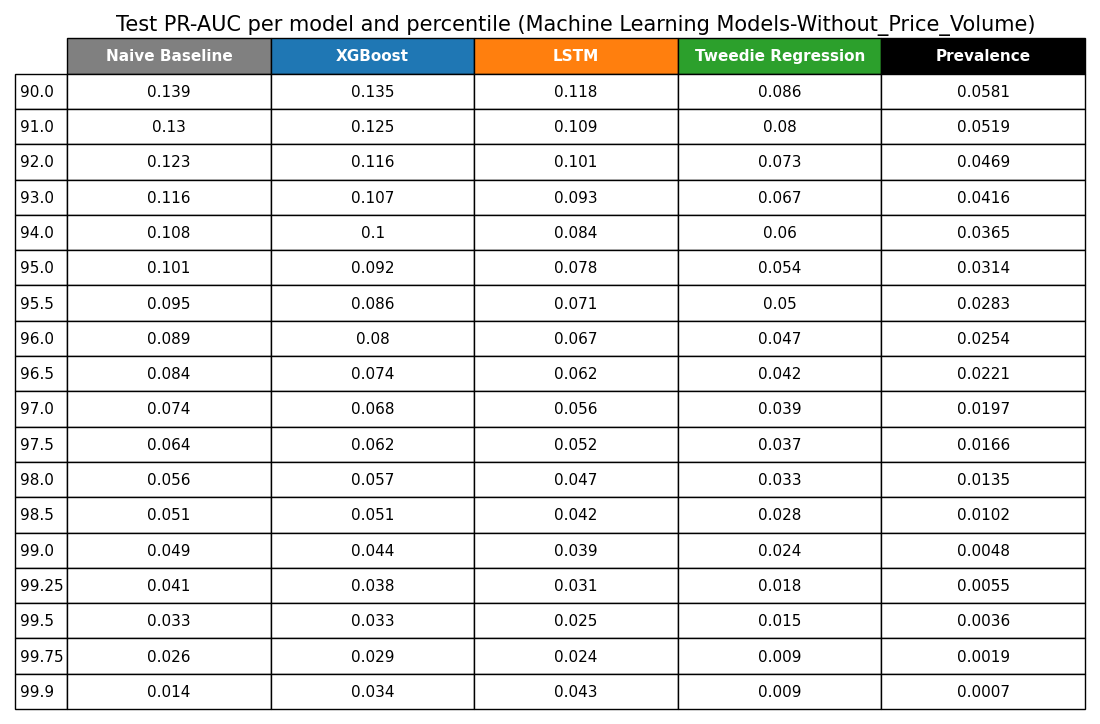

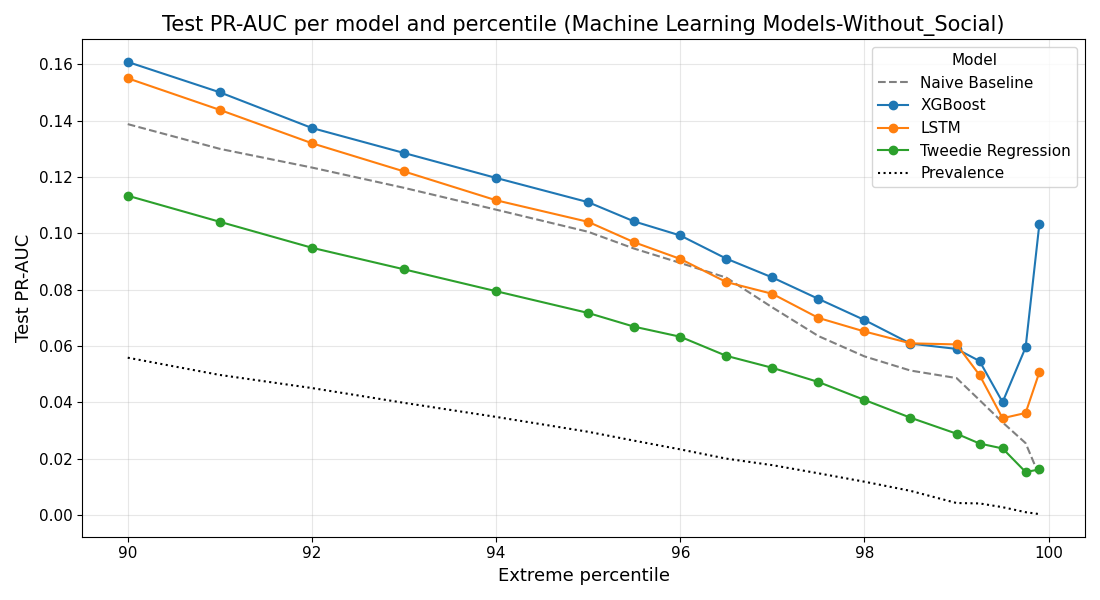

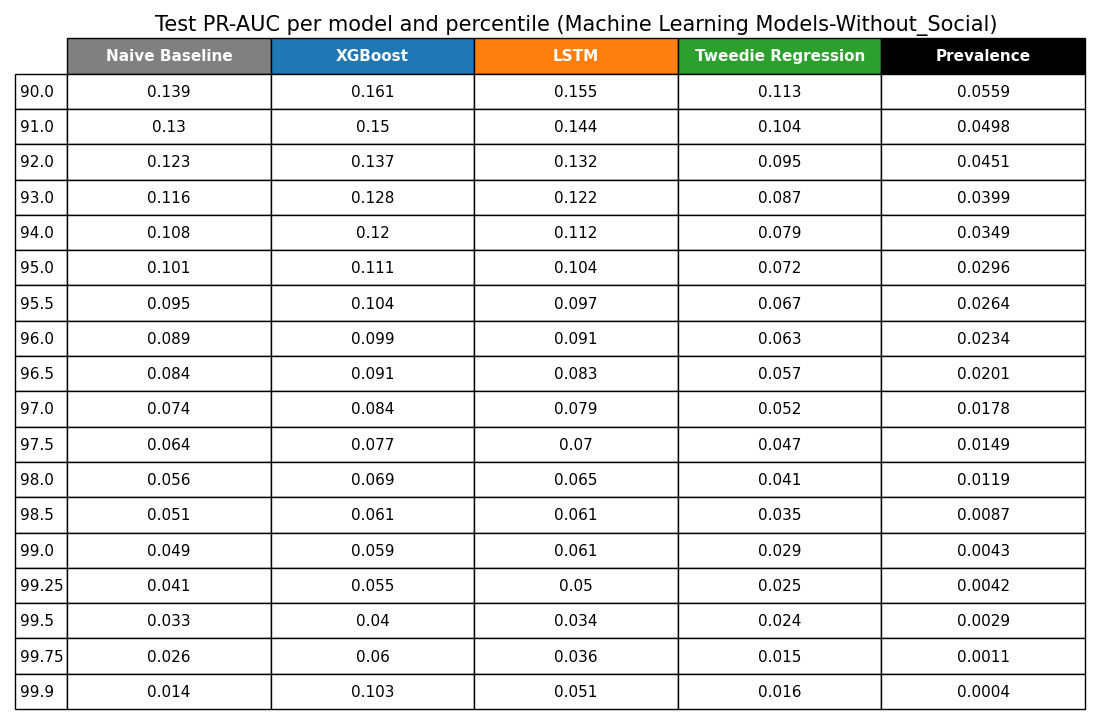

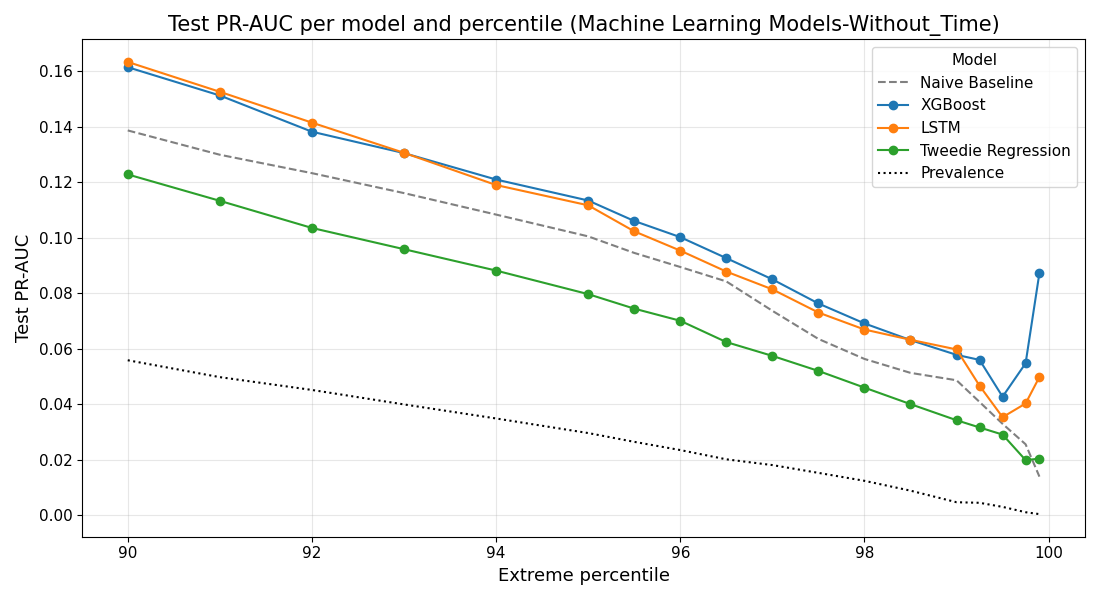

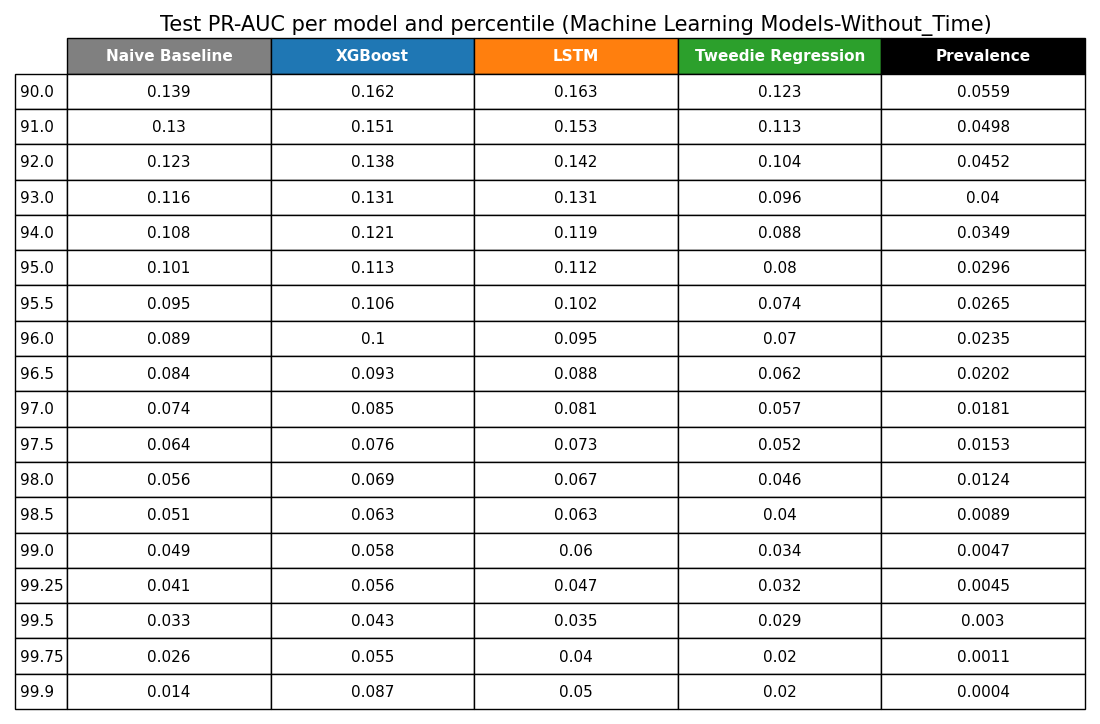

In [10]:

script_names = df_extreme_sensitivity['Script name'].unique()
MODEL_ORDER = ['Naive Baseline', 'XGBoost', 'LSTM', 'Tweedie Regression']

for script in script_names:
    subset = df_extreme_sensitivity[df_extreme_sensitivity['Script name'] == script].copy()
    title = f'Test PR-AUC per model and percentile ({script})'

    available = list(subset['Model'].unique())
    order_lower = {m.lower(): m for m in MODEL_ORDER}
    models = [order_lower[m.lower()] if m.lower() in order_lower else m for m in available]
    models = sorted(models, key=lambda m: MODEL_ORDER.index(m) if m in MODEL_ORDER else len(MODEL_ORDER))

    # prevalence line
    with np.errstate(divide='ignore', invalid='ignore'):
        subset['Prevalence'] = (subset['Test PR-AUC'] / subset['PR-AUC lift over random'])
    subset.loc[~np.isfinite(subset['Prevalence']), 'Prevalence'] = np.nan
    prevalence = (subset.groupby('Extreme percentile')['Prevalence'].mean().sort_index().dropna())

    # colours
    model_colors = {}
    for model in models:
        is_naive = 'naive' in model.lower()
        if is_naive:
            model_colors[model] = 'grey'

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    non_naive = [m for m in models if m not in model_colors]
    for i, model in enumerate(non_naive):
        model_colors[model] = color_cycle[i % len(color_cycle)]

    # chart 
    fig, ax = plt.subplots(figsize=(11, 6))
    for model in models:
        model_df = subset[subset['Model'] == model].sort_values('Extreme percentile')
        is_naive = 'naive' in model.lower()
        ax.plot(model_df['Extreme percentile'], model_df['Test PR-AUC'],marker=None if is_naive else 'o',linestyle='--' if is_naive else '-',color=model_colors[model],label=model)

    if not prevalence.empty:
        ax.plot(prevalence.index, prevalence.values,linestyle=':', color='black', linewidth=1.5,label='Prevalence')

    ax.set_title(title, fontsize=15)
    ax.set_xlabel('Extreme percentile', fontsize=13)
    ax.set_ylabel('Test PR-AUC', fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(title='Model', fontsize=11, title_fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # table 
    pivot = subset.pivot_table(index='Extreme percentile', columns='Model', values='Test PR-AUC').sort_index()
    pivot = pivot[models]
    pivot = pivot.round(3)

    if not prevalence.empty:
        pivot['Prevalence'] = prevalence.round(4)

    n_rows = len(pivot) + 1
    table_height = n_rows * 0.35 + 0.6

    tfig, tax = plt.subplots(figsize=(11, table_height))
    tax.axis('off')
    tax.set_title(title, fontsize=15, pad=6)
    table = tax.table(cellText=pivot.values,rowLabels=pivot.index,colLabels=pivot.columns,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    for col_idx, model in enumerate(pivot.columns):
        cell = table[(0, col_idx)]
        cell.set_facecolor(model_colors.get(model, 'black'))
        cell.set_text_props(color='white', weight='bold')

    plt.tight_layout()
    plt.show()

### Ablation study on PR-AUC

In [11]:

full_script = [s for s in df_extreme_sensitivity['Script name'].unique() if 'horizon12' in s.lower()][0]
feature_scripts = [s for s in df_extreme_sensitivity['Script name'].unique() if 'without_' in s.lower()]

full_df = df_extreme_sensitivity[(df_extreme_sensitivity['Script name'] == full_script) &(~df_extreme_sensitivity['Model'].str.lower().str.contains('naive'))]

rows = []
for script in feature_scripts:
    feature_group = script.split('Without_')[-1] 
    variant_df = df_extreme_sensitivity[(df_extreme_sensitivity['Script name'] == script) &(~df_extreme_sensitivity['Model'].str.lower().str.contains('naive'))]
    
    merged = variant_df.merge(full_df,on=['Extreme percentile', 'Model'],suffixes=('_without', '_full'))
    merged['pr_auc_change'] = merged['Test PR-AUC_without'] - merged['Test PR-AUC_full']
    
    avg_change = merged.groupby('Model')['pr_auc_change'].mean()
    avg_change.name = feature_group
    rows.append(avg_change)

ablation = pd.DataFrame(rows) 
ablation = ablation.round(4)
ablation

Model,LSTM,Tweedie Regression,XGBoost
Coin,0.0016,-0.0018,0.0026
Funding_Positioning,0.0013,0.0011,-0.0020
Onchain,0.0056,-0.0031,0.0017
Open_Interest,-0.0064,-0.0007,-0.0072
Order_Book,-0.0051,0.0004,0.0029
Price_Volume,-0.0230,-0.0172,-0.0203
Social,-0.0006,-0.0033,0.0008
Time,0.0036,0.0033,0.0007


C:\Users\admin\AppData\Local\Temp\ipykernel_22312\2210977815.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  red_green = cm.get_cmap('RdYlGn')


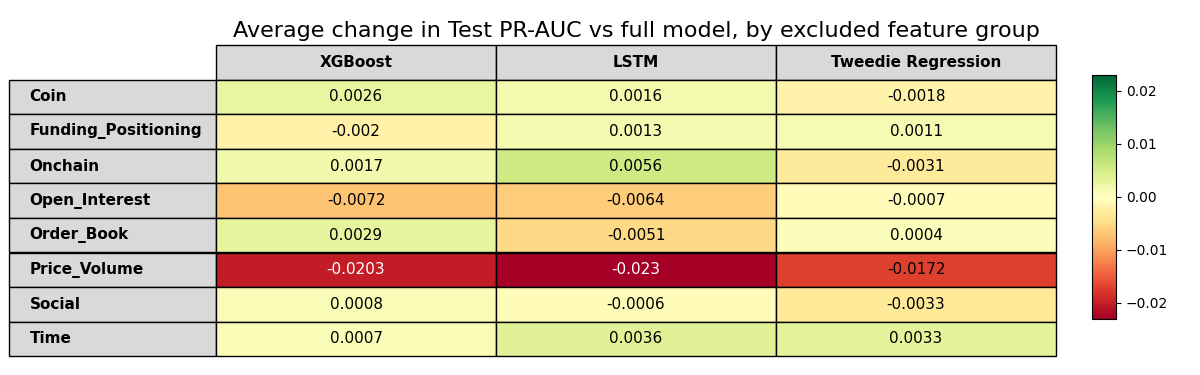

In [12]:

MODEL_ORDER = ['XGBoost', 'LSTM', 'Tweedie Regression']
models = [m for m in MODEL_ORDER if m in ablation.columns]
ablation = ablation[models]

n_rows = len(ablation) + 1
table_height = n_rows * 0.35 + 0.6
fig, ax = plt.subplots(figsize=(12, table_height))
ax.axis('off')
ax.set_title('Average change in Test PR-AUC vs full model, by excluded feature group', fontsize=16, pad=6)
table = ax.table(cellText=ablation.values,rowLabels=ablation.index,colLabels=ablation.columns,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)

# column headers formatting
for col_idx in range(len(ablation.columns)):
    cell = table[(0, col_idx)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')
    
# row headers formatting
for row_idx in range(1, len(ablation) + 1):
    cell = table[(row_idx, -1)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')
    
# colour scale for conditional formatting
red_green = cm.get_cmap('RdYlGn')
max_abs = ablation.values.max() if abs(ablation.values.max()) > abs(ablation.values.min()) else abs(ablation.values.min())
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
for row_idx, feature_group in enumerate(ablation.index, start=1):
    for col_idx, model in enumerate(ablation.columns):
        val = ablation.loc[feature_group, model]
        cell = table[(row_idx, col_idx)]
        cell.set_facecolor(red_green(norm(val)))
        intensity = abs(norm(val) - 0.5) * 2
        cell.set_text_props(color='white' if intensity > 0.75 else 'black')
        
fig.subplots_adjust(left=0.18, right=0.88, top=0.88, bottom=0.05)

# color scale bar
cax = fig.add_axes([0.91, 0.15, 0.02, 0.65])
sm = cm.ScalarMappable(norm=norm, cmap=red_green)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
plt.show()

## F1-Score Charts

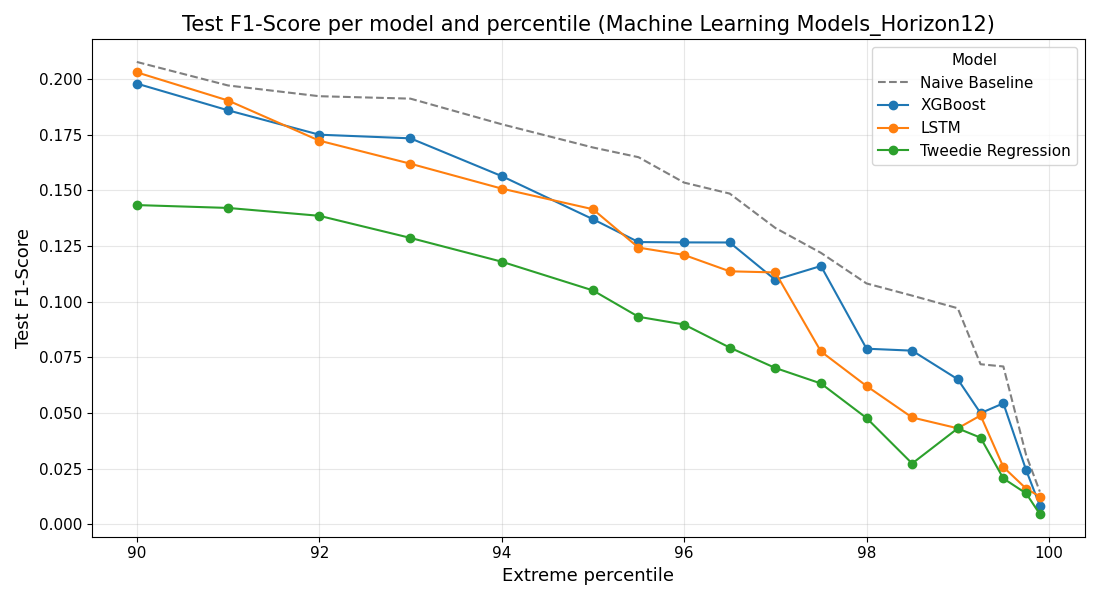

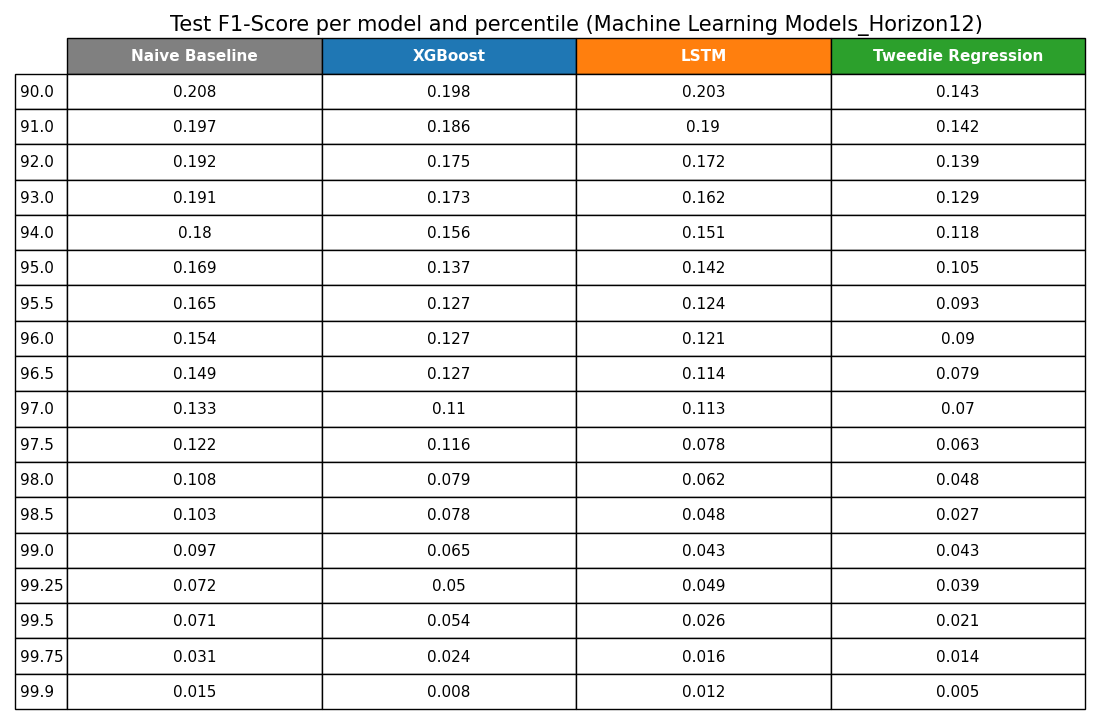

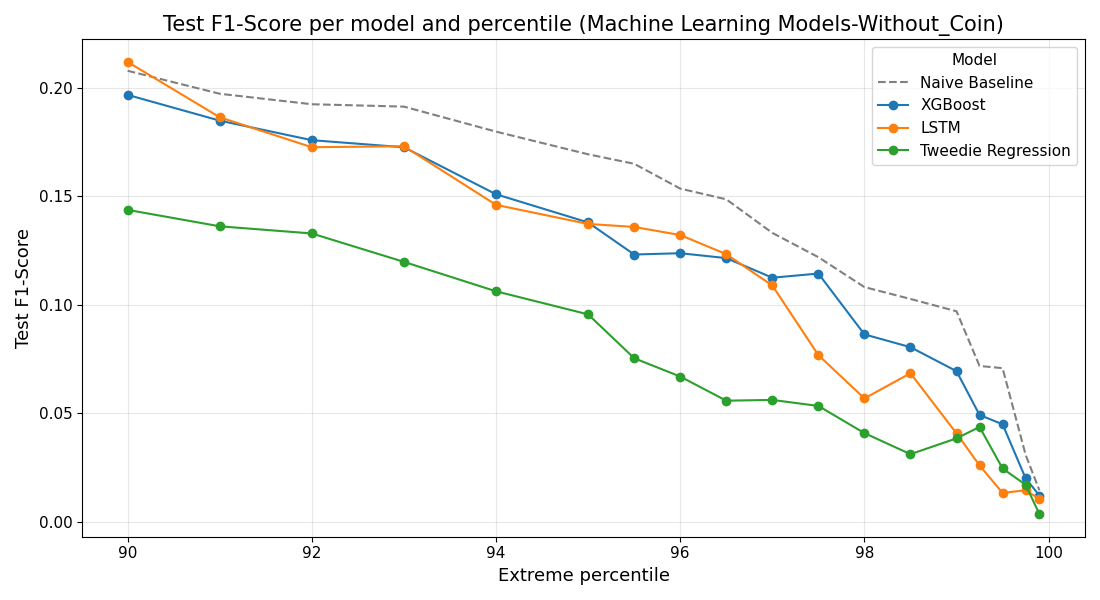

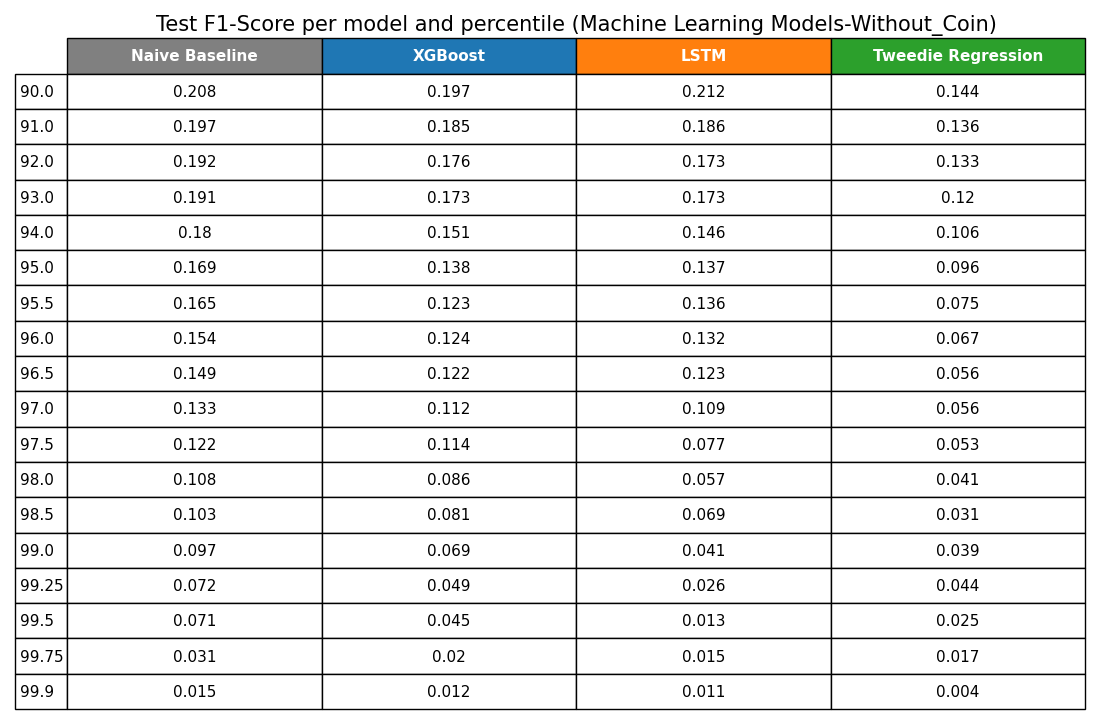

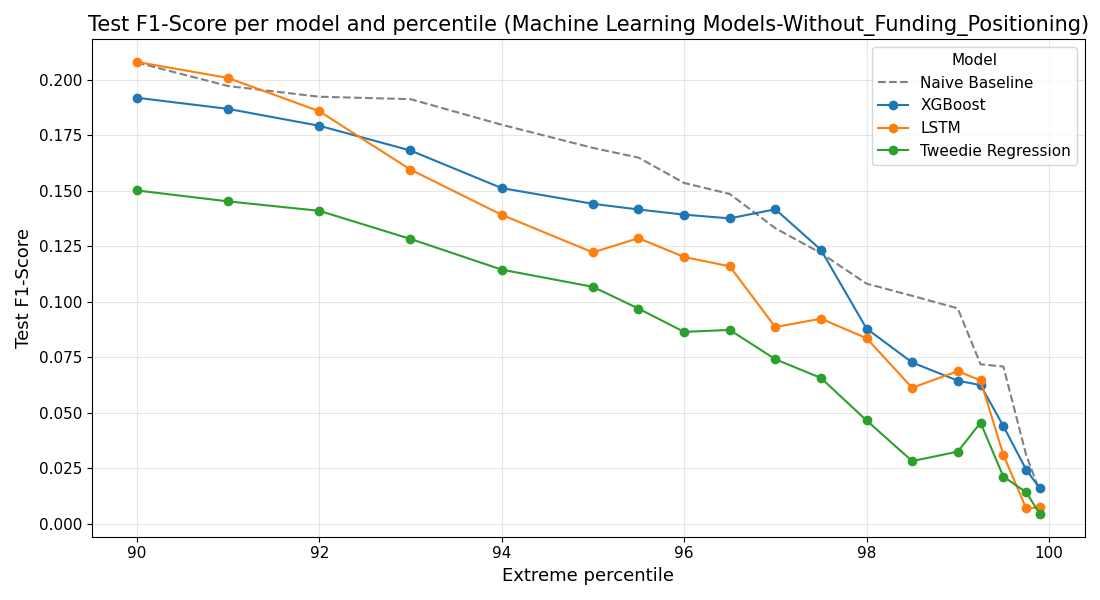

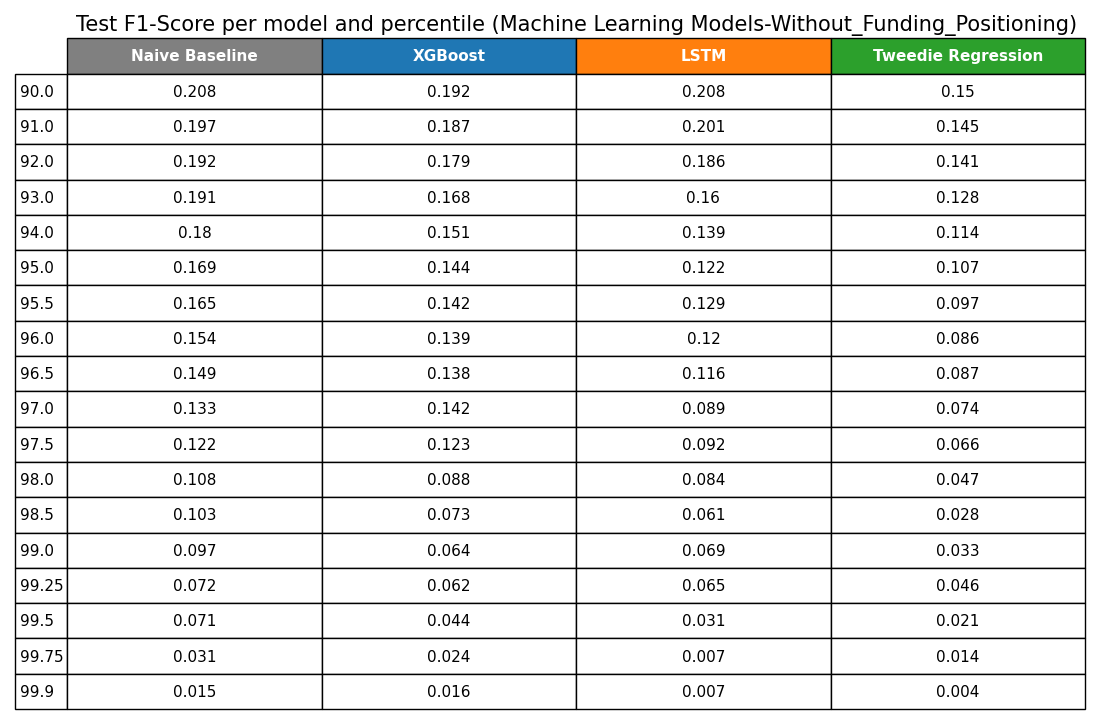

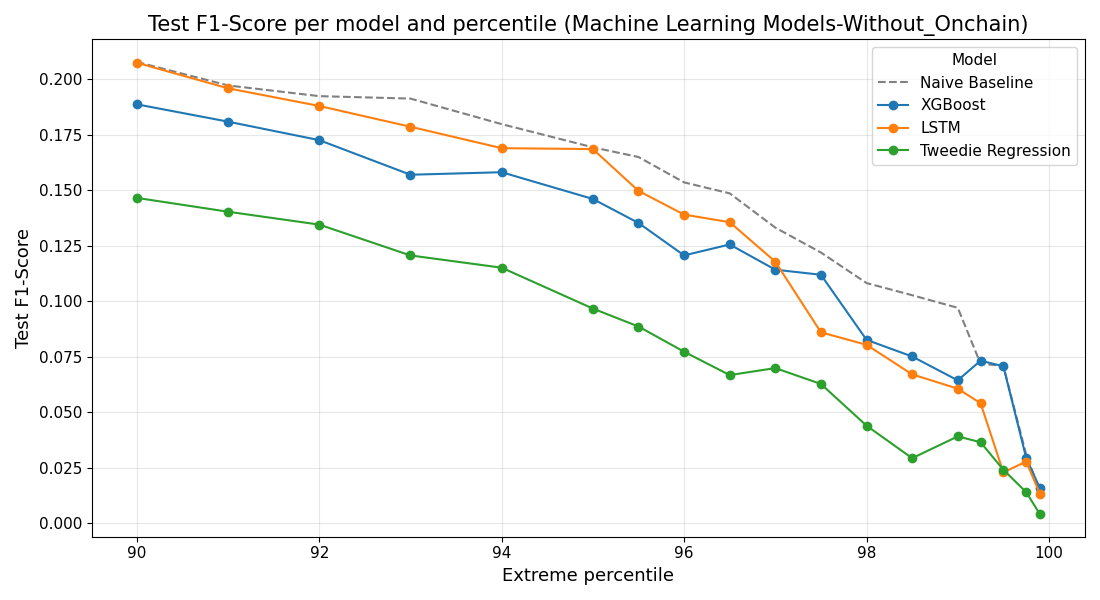

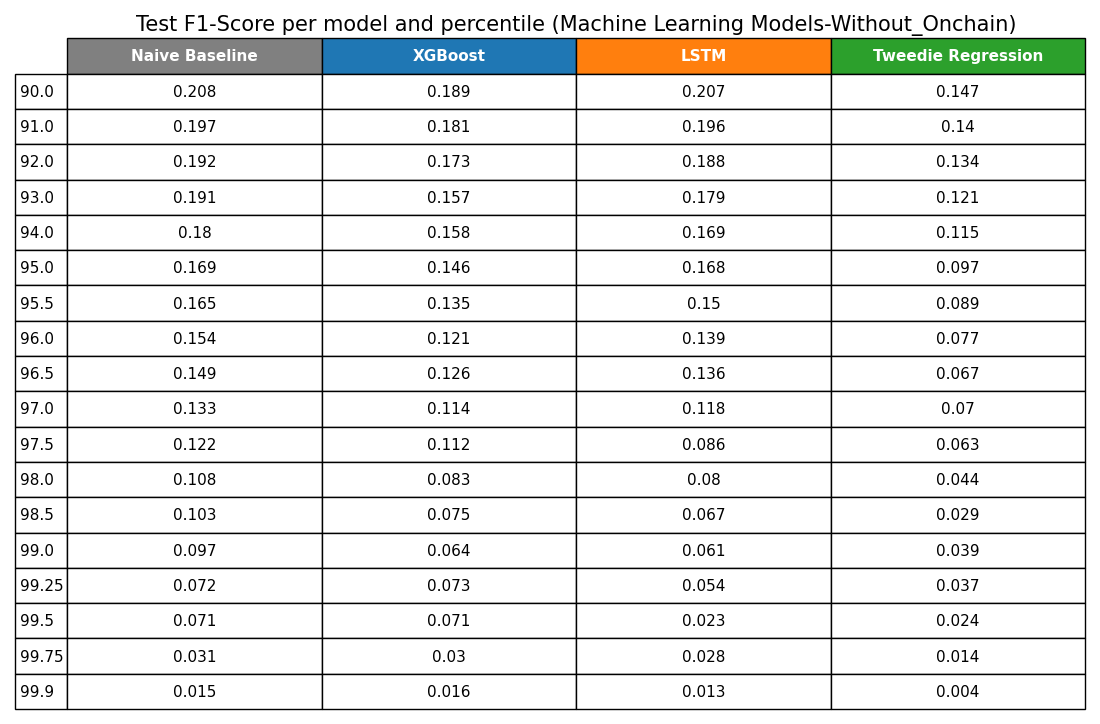

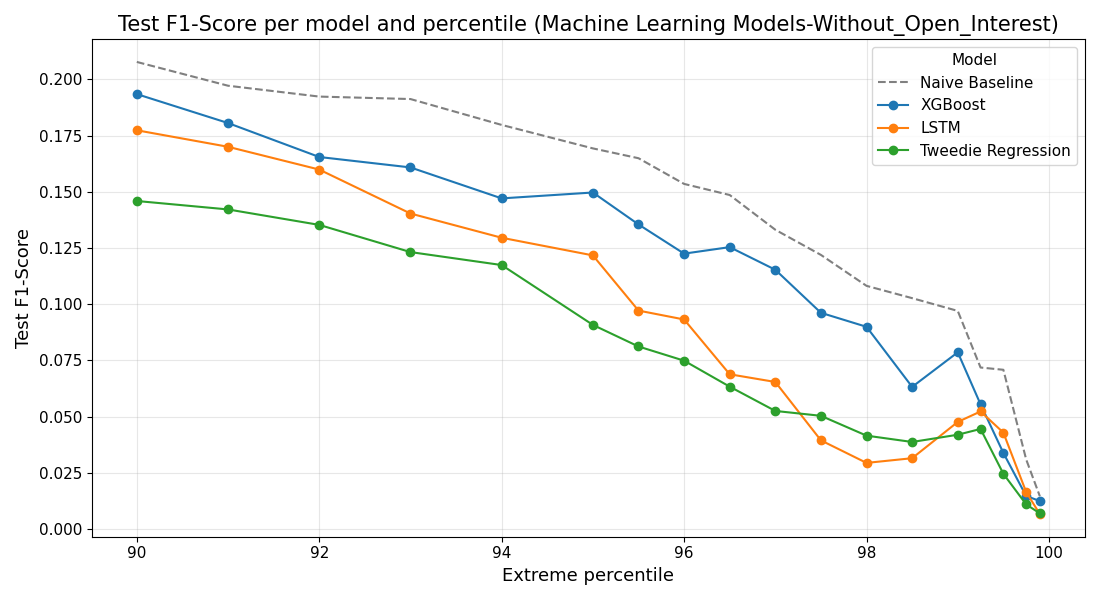

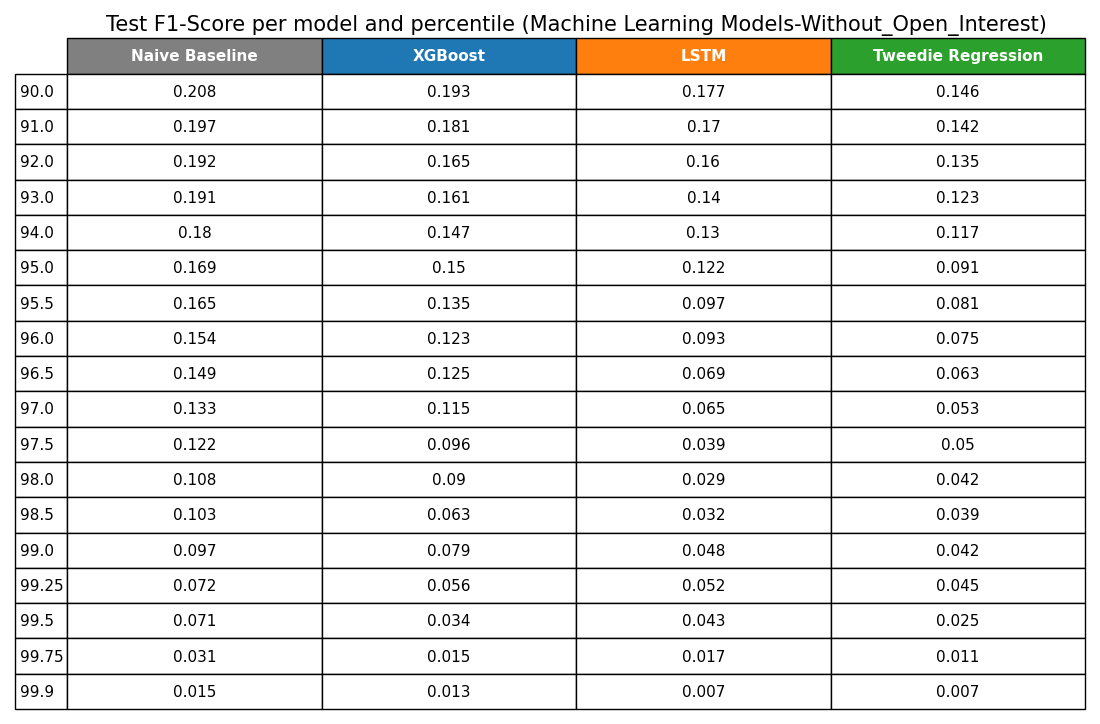

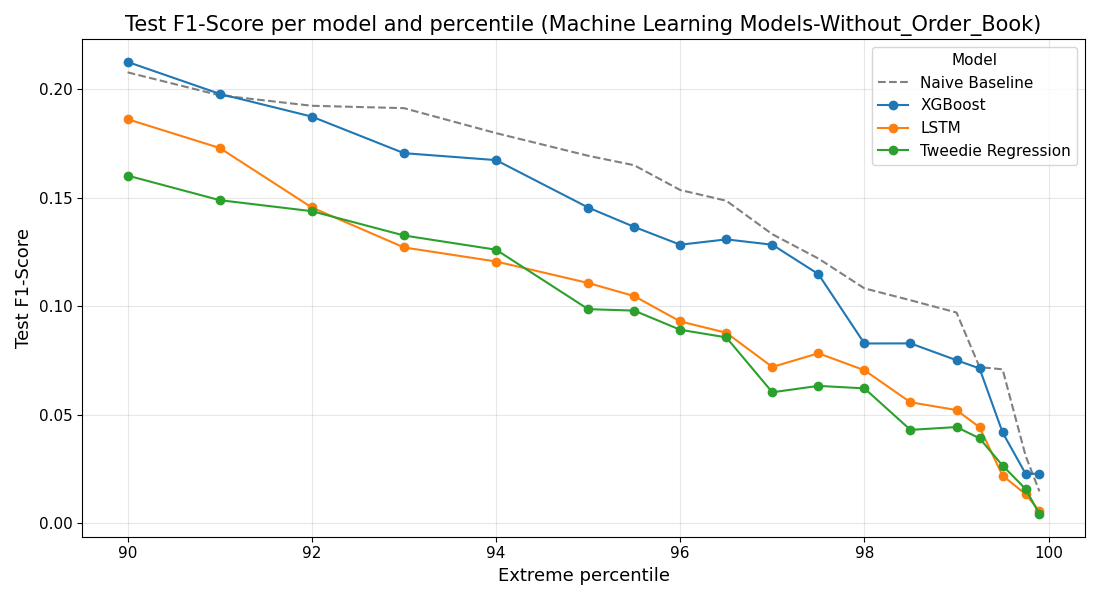

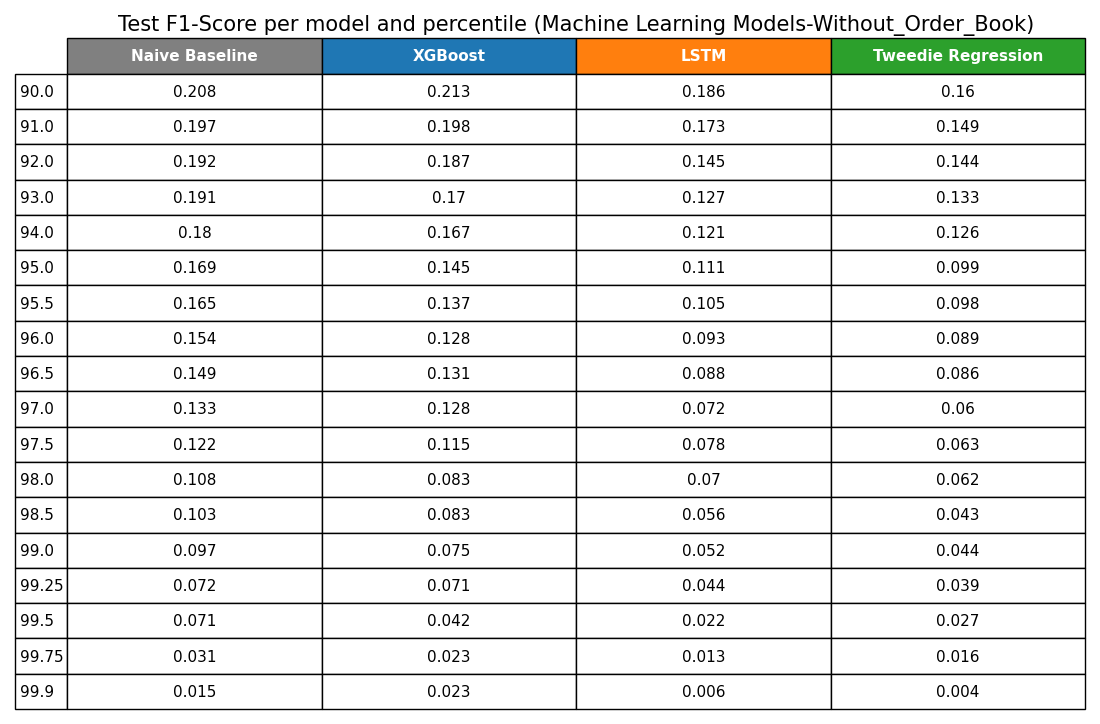

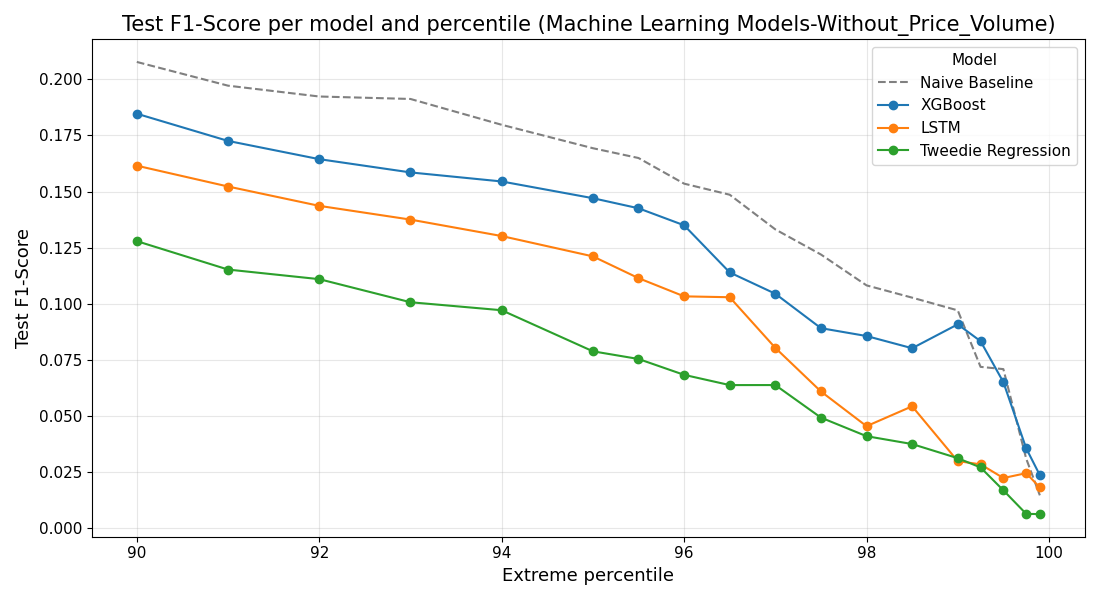

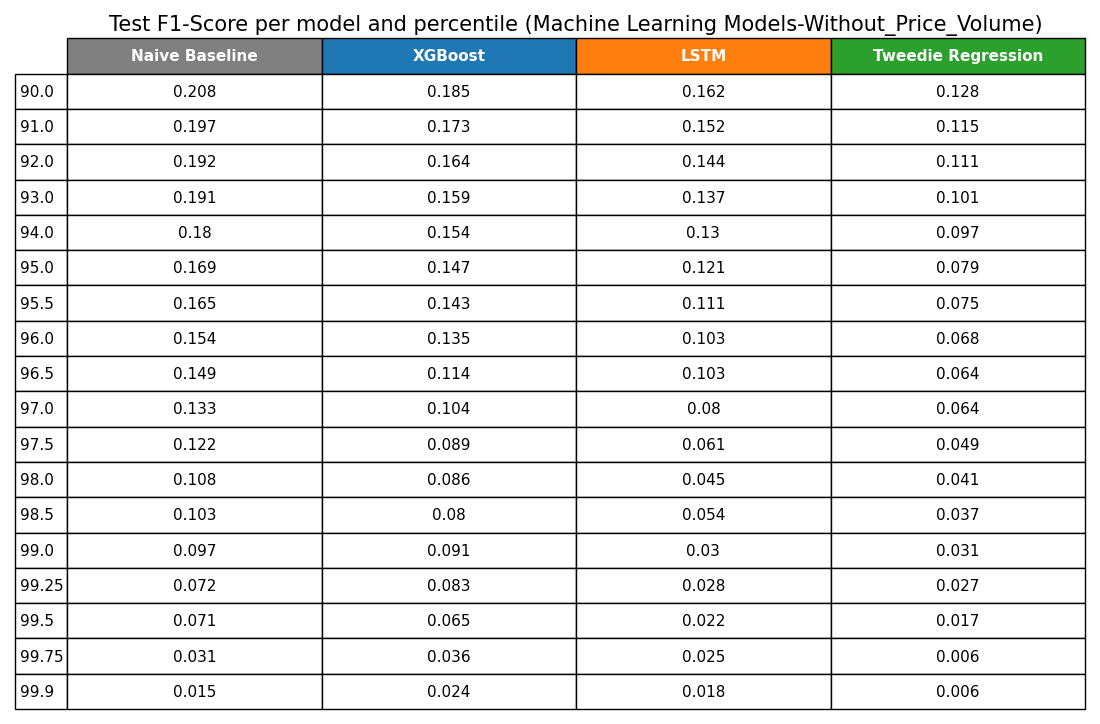

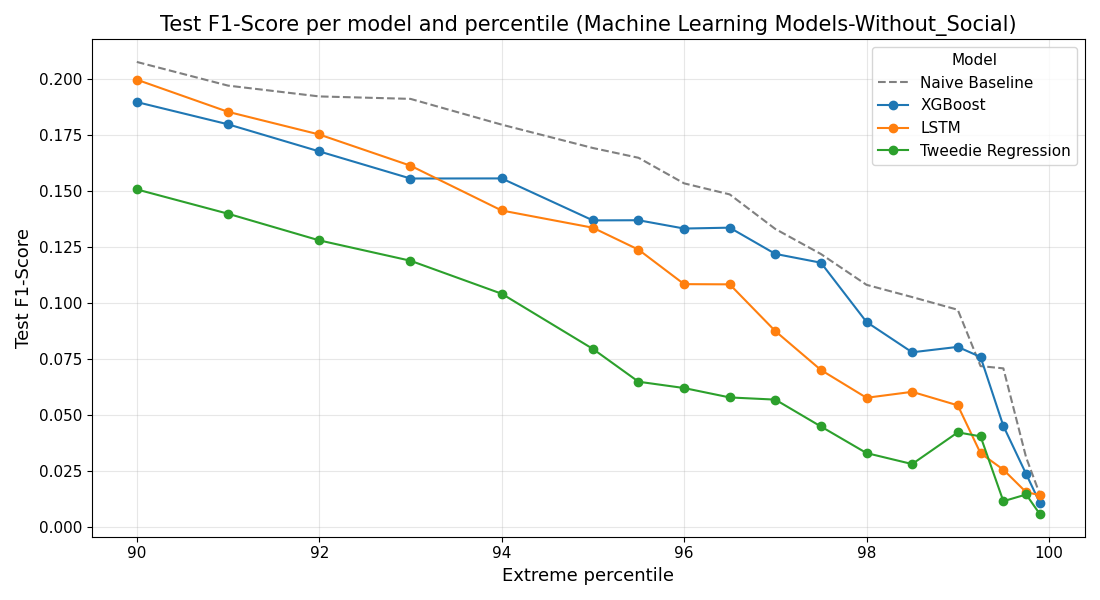

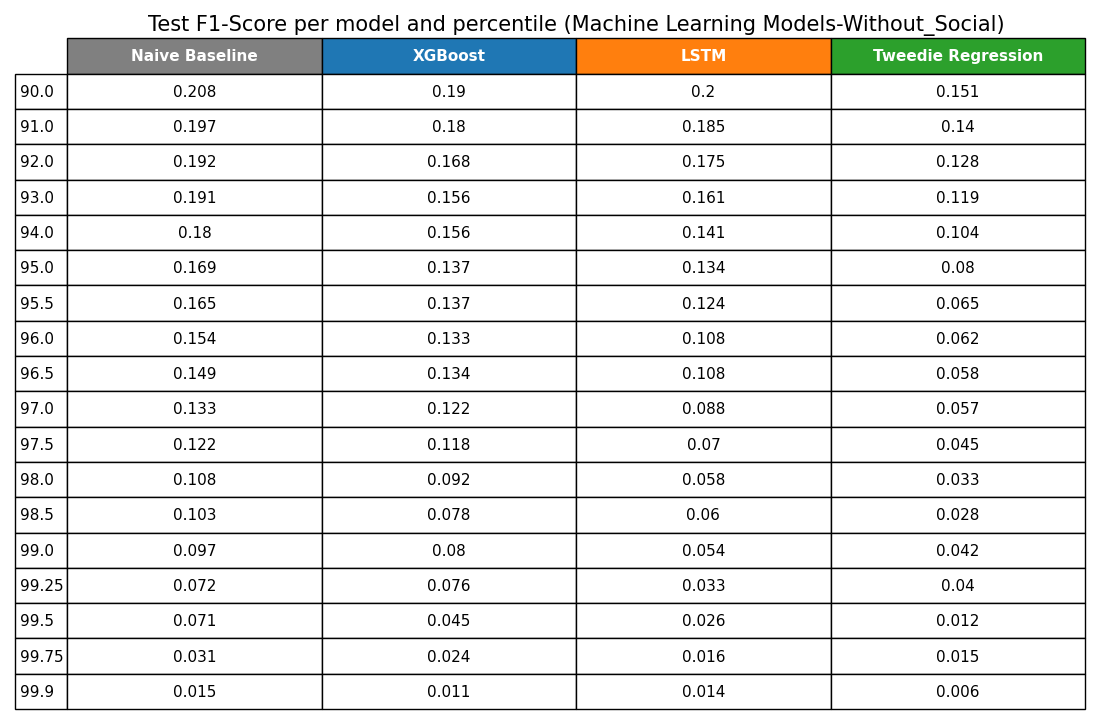

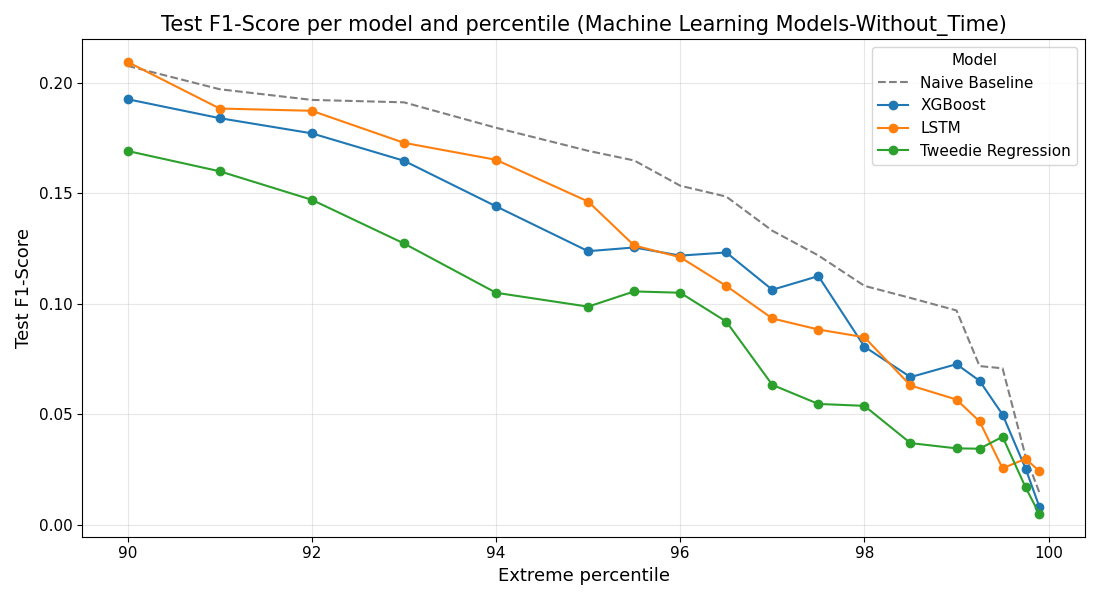

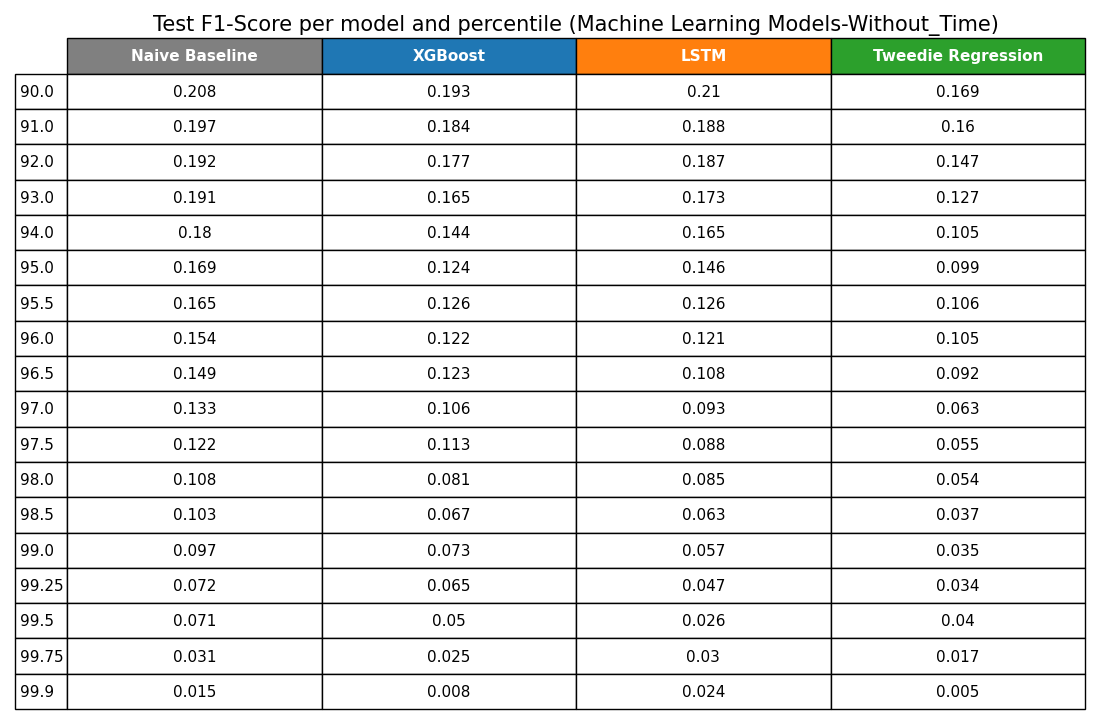

In [16]:

script_names = df_extreme_sensitivity['Script name'].unique()
MODEL_ORDER = ['Naive Baseline', 'XGBoost', 'LSTM', 'Tweedie Regression']

for script in script_names:
    subset = df_extreme_sensitivity[df_extreme_sensitivity['Script name'] == script]
    title = f'Test F1-Score per model and percentile ({script})'
    
    available = list(subset['Model'].unique())
    order_lower = {m.lower(): m for m in MODEL_ORDER}
    models = [order_lower[m.lower()] if m.lower() in order_lower else m for m in available]
    models = sorted(models, key=lambda m: MODEL_ORDER.index(m) if m in MODEL_ORDER else len(MODEL_ORDER))
    
    # colour
    model_colors = {}
    for model in models:
        is_naive = 'naive' in model.lower()
        if is_naive:
            model_colors[model] = 'grey'
    
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    non_naive = [m for m in models if m not in model_colors]
    for i, model in enumerate(non_naive):
        model_colors[model] = color_cycle[i % len(color_cycle)]
    
    # chart 
    fig, ax = plt.subplots(figsize=(11, 6))
    for model in models:
        model_df = subset[subset['Model'] == model].sort_values('Extreme percentile')
        is_naive = 'naive' in model.lower()
        ax.plot(model_df['Extreme percentile'], model_df['Test F1'],marker=None if is_naive else 'o',linestyle='--' if is_naive else '-',color=model_colors[model],label=model)
    
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('Extreme percentile', fontsize=13)
    ax.set_ylabel('Test F1-Score', fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(title='Model', fontsize=11, title_fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # table
    pivot = subset.pivot_table(
        index='Extreme percentile', columns='Model', values='Test F1'
    ).sort_index()
    pivot = pivot[models]
    pivot = pivot.round(3)
    
    n_rows = len(pivot) + 1
    table_height = n_rows * 0.35 + 0.6
    
    tfig, tax = plt.subplots(figsize=(11, table_height))
    tax.axis('off')
    tax.set_title(title, fontsize=15, pad=6)
    table = tax.table(cellText=pivot.values,rowLabels=pivot.index,colLabels=pivot.columns,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for col_idx, model in enumerate(pivot.columns):
        cell = table[(0, col_idx)]
        cell.set_facecolor(model_colors[model])
        cell.set_text_props(color='white', weight='bold')
    
    plt.tight_layout()
    plt.show()

## Ablation study on F1-Score

In [17]:

full_script = [s for s in df_extreme_sensitivity['Script name'].unique() if 'horizon12' in s.lower()][0]
feature_scripts = [s for s in df_extreme_sensitivity['Script name'].unique() if 'without_' in s.lower()]
full_df = df_extreme_sensitivity[(df_extreme_sensitivity['Script name'] == full_script) &(~df_extreme_sensitivity['Model'].str.lower().str.contains('naive'))]
rows = []
for script in feature_scripts:
    feature_group = script.split('Without_')[-1]
    variant_df = df_extreme_sensitivity[(df_extreme_sensitivity['Script name'] == script) &(~df_extreme_sensitivity['Model'].str.lower().str.contains('naive'))]
    
    merged = variant_df.merge(full_df,on=['Extreme percentile', 'Model'],suffixes=('_without', '_full'))
    merged['f1_change'] = merged['Test F1_without'] - merged['Test F1_full']
    
    avg_change = merged.groupby('Model')['f1_change'].mean()
    avg_change.name = feature_group
    rows.append(avg_change)
ablation_f1 = pd.DataFrame(rows) 
ablation_f1 = ablation_f1.round(4)
ablation_f1

Model,LSTM,Tweedie Regression,XGBoost
Coin,0.0005,-0.0069,-0.0007
Funding_Positioning,0.0033,0.0012,0.0048
Onchain,0.0131,-0.0032,0.0017
Open_Interest,-0.0186,-0.0045,-0.0028
Order_Book,-0.0147,0.0041,0.0071
Price_Volume,-0.0165,-0.0139,0.0022
Social,-0.0039,-0.0102,0.0025
Time,0.0063,0.0046,-0.0025


C:\Users\admin\AppData\Local\Temp\ipykernel_22312\1513699001.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  red_green = cm.get_cmap('RdYlGn')


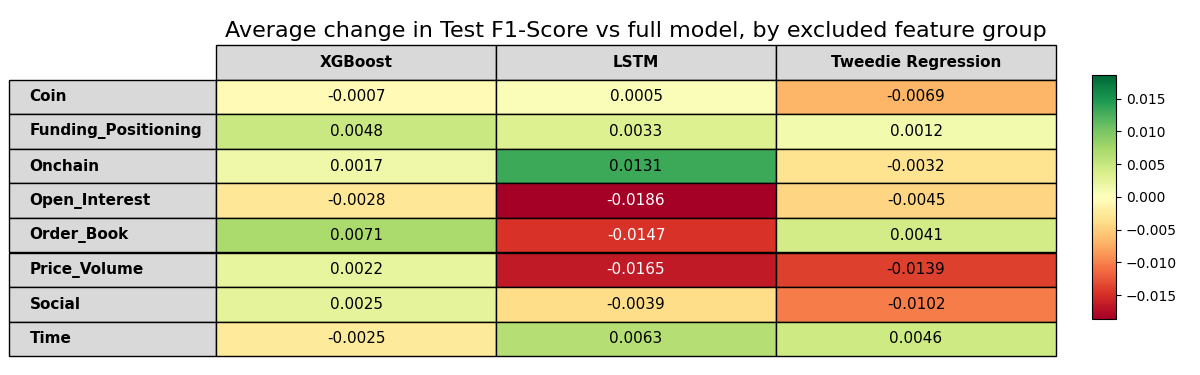

In [18]:

MODEL_ORDER = ['XGBoost', 'LSTM', 'Tweedie Regression']
models = [m for m in ['XGBoost', 'LSTM', 'Tweedie Regression'] if m in ablation_f1.columns]
ablation_f1 = ablation_f1[models]

n_rows = len(ablation_f1) + 1
table_height = n_rows * 0.35 + 0.6
fig, ax = plt.subplots(figsize=(12, table_height))
ax.axis('off')
ax.set_title('Average change in Test F1-Score vs full model, by excluded feature group', fontsize=16, pad=6)
table = ax.table(cellText=ablation_f1.values,rowLabels=ablation_f1.index,colLabels=ablation_f1.columns,cellLoc='center',loc='center',bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)

# column headerss formatting
for col_idx in range(len(ablation_f1.columns)):
    cell = table[(0, col_idx)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')
    
# row headers formatting
for row_idx in range(1, len(ablation_f1) + 1):
    cell = table[(row_idx, -1)]
    cell.set_facecolor('#d9d9d9')
    cell.set_text_props(color='black', weight='bold')
    
# colour scale for conditional formatting
red_green = cm.get_cmap('RdYlGn')
max_abs = ablation_f1.values.max() if abs(ablation_f1.values.max()) > abs(ablation_f1.values.min()) else abs(ablation_f1.values.min())
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
for row_idx, feature_group in enumerate(ablation_f1.index, start=1):
    for col_idx, model in enumerate(ablation_f1.columns):
        val = ablation_f1.loc[feature_group, model]
        cell = table[(row_idx, col_idx)]
        cell.set_facecolor(red_green(norm(val)))
        intensity = abs(norm(val) - 0.5) * 2
        cell.set_text_props(color='white' if intensity > 0.75 else 'black')

fig.subplots_adjust(left=0.18, right=0.88, top=0.88, bottom=0.05)

# color scale bar
cax = fig.add_axes([0.91, 0.15, 0.02, 0.65])
sm = cm.ScalarMappable(norm=norm, cmap=red_green)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
plt.show()